## 1. Importing Required Libraries and Set Up of the Environment

In the following section we import all the libraries used in our project. Further informations can be gathered in the requirements.txt file

In [ ]:
# install depndencies from requirements.txt
# !pip install -r requirements.txt

In [1]:
# standard libraries
import os
import pathlib
import random
from collections import Counter
import time
from itertools import product
import requests
import zipfile
import io

# data processing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import hashlib
from tqdm import tqdm

# image processing
from PIL import Image

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [2]:
# Set a seed for reproducibility
SEED = 42

def set_global_seed(seed=42):
    import os
    import random
    import numpy as np
    import tensorflow as tf

    os.environ['PYTHONHASHSEED'] = str(seed)
    os.environ['TF_DETERMINISTIC_OPS'] = '1'  # Optional
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    return

set_global_seed(SEED)

## 2. Data Collection and Exploration

Here we analyze the structure of the directory.  
  
Each subdirectory in "data/" represents a waste class (e.g. 'Plastic', 'Glass'...) and contains jpg images of wastes belonging to that specific class.  
  
To understand the structure of the directory we implemented several functions to verify that:
- there are not waste classes without images, 
- there are not unexpected file formats, 
- there are not duplicated images,
- the dataset is balanced.  

Functions:
- print_className_nFiles_types(dir) prints the directory name, the number of files it contains and the file extensions of those files.
- get_dirs_inside_dir(data_dir) given a main directory applies print_className_nFiles_types(dir) to all the subdirectories, then retrieves the images file paths and it returns a dictionary where the keys are the names of the subdirectories and the values are lists of paths of images inside those directories.
- plot_class_distribution(imgs_dict) which plots the distribution of the images by waste class
- get_md5_hash(image_path) returns a md5 has of an image
- get_duplicates(directory) checks whether directory has one or more duplicated images

In [4]:
# Given a directory, it prints name, number of files and types of files e.g. "- Paper |  500 files | Types: .jpg"
def print_className_nFiles_types(dir):
    name= dir.name.ljust(20)
    files= list(dir.glob('*'))
    extensions= {path.suffix.lower() for path in files}
    print(f"- {name} | {str(len(files)).rjust(4)} files | Types: {', '.join(extensions)}")

# For each directory inside the data_dir, the function prints the name, the number of files and the types of files e.g. "- Paper |  500 files | Types: .jpg"
# and then in returns:
# - imgs_dict: a dictionary where keys are the names of the dirs and the values are lists of paths of images inside those directories
def get_dirs_inside_dir(data_dir):
    data_dir = pathlib.Path(data_dir)
    dirs= [dir for dir in data_dir.iterdir() if dir.is_dir()] # get all the directories inside the data_dir

    imgs_dict= {} # initialize a dic to store the images

    # print and get info about the directories
    print("Extraction completed. \n")
    print(f"Found {len(dirs)} directories in {data_dir}:") # number of directories in data_dir e.g. "Found 9 directories in waste_data:"

    for dir in dirs: # loop through each directory
        imgs_dict[dir.name]= list(dir.glob('*')) #put the images inside imgs_dict[dir.name]

        dir_unique_img_extensions = set() # initialize a set to store unique image extensions
        for path in dir.glob('*'):
            dir_unique_img_extensions.add(path.suffix)

        print_className_nFiles_types(dir) # print the name, n files and types e.g. "- Paper |  500 files | Types: .jpg"

    return imgs_dict

# extract the images and labels from 'data'
data_directory= 'data'
imgs_dict= get_dirs_inside_dir(data_directory)

Extraction completed. 

Found 9 directories in data:
- Paper                |  500 files | Types: .jpg
- Metal                |  790 files | Types: .jpg
- Cardboard            |  461 files | Types: .jpg
- Food Organics        |  411 files | Types: .jpg
- Glass                |  420 files | Types: .jpg
- Vegetation           |  436 files | Types: .jpg
- Textile Trash        |  318 files | Types: .jpg
- Miscellaneous Trash  |  495 files | Types: .jpg
- Plastic              |  921 files | Types: .jpg


In [5]:
# It takes an image path and returns a md5 hash of the image
def get_md5_hash(image_path):
    with open(image_path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

# It takes a directory as input and returns a list of images that are duplicated
def get_duplicates(directory):
    print("Searching for duplicates...")
    md5_hashes = {}
    duplicates = []

    for root, _, images in os.walk(directory):
        for image_name in images:
            image_path = os.path.join(root, image_name)
            md5_hash = get_md5_hash(image_path)
            if md5_hash in md5_hashes:
                duplicates.append((image_path, md5_hashes[md5_hash]))
            else:
                md5_hashes[md5_hash] = image_path

    if len(duplicates)>0:
        print(f"Found {len(duplicates)} duplicate images. \n")
        for duplicate in duplicates:
            print(f"Duplicate found:\n{duplicate[0]}\n{duplicate[1]}\n")
    else:
        print("No duplicates found.")
    return duplicates

duplicates= get_duplicates(data_directory)

Searching for duplicates...
No duplicates found.


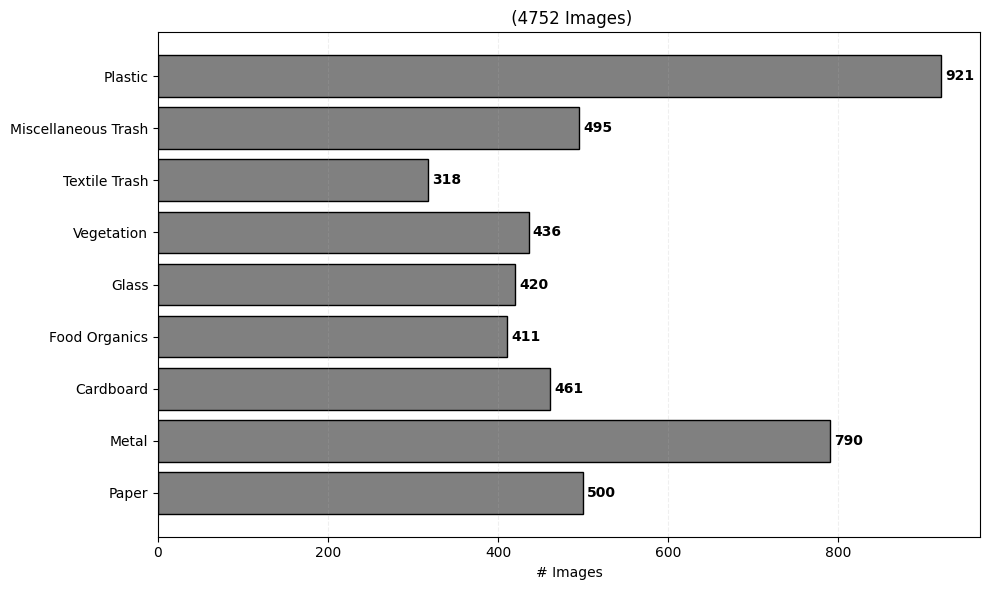

In [31]:
# It plots the class distribution of the imgs in the different classes given either imgs_dict or y_labels and class_map
def plot_class_distribution(imgs_dict= None, y_labels= None, class_map=None, title= ""):
    if imgs_dict != None: # if input is imgs_dict
        # classes and counts
        classes= list(imgs_dict.keys())
        counts= [len(imgs_dict[img_class]) for img_class in classes]
    elif (y_labels is not None) and (class_map is not None): # if input is a list of labels and a class map
        # classes and counts
        class_distribution = Counter(y_labels)
        classes = list(class_map.keys())
        counts= [class_distribution[i] for i in class_map.values()]

    else:
        print("Either imgs_dict or y_labels and class_map must be provided.")

    # set the fig size
    plt.figure(figsize=(10, 6))

    # define the bars
    bars= plt.barh(classes, counts, edgecolor='black', color='grey')
    for bar in bars:
        xval= bar.get_width()
        plt.text(xval + 5, bar.get_y() + bar.get_height()/2, xval,
                 va='center', ha='left', fontweight='bold')
    
    # fig settings
    plt.title(f"{title} ({sum(counts)} Images)")
    plt.xlabel("# Images")
    plt.grid(axis='x', linestyle='--', alpha=0.2)
    plt.tight_layout()
    plt.show()

plot_class_distribution(imgs_dict)

## 3. Data Preprocessing

Here we preprocess the images to prepare them for training the SVMs and CNNs models.

What we do in this section:
- Define and use get_X_y_classmap(imgs_dict, image_size= ) to load the images and then resize, transform to RGB and normal pixel values. Finally it returns a 3d and 1 version of the images, an array with a label of the waste class and the class_map mapping dictionary.
- Define and use plot_imgs_grid_from_array(X, y, class_map, imgs_per_class= , save_img= , output_path= ) plots x images for each waste class in a grid, we use it to grab an overview of the dataset
- Split the dataset into a train, validation and test set
- Define and use augment_image(image) and dataset_augmentation_to_target(X_train, y_train, target_size_per_class= , batch_size= ) to augment images and reach balance inside the training set
- Define and use get_class_distribution_table(y_train, y_val, y_test, class_map, y_train_balanced= ) to show a table with the distribution of images within the different waste class in the train, valid and test set

In [7]:
# Load the images in a 3d (CNNs) and 1d (SVMs) formats (after resizing, converting to RGB and normalizing the images)
# It returns 4 variables: the 3d version of the images for CNNs, the 1d version of the images for SVMs, the labels and a class map
def get_X_y_classmap(imgs_dict, image_size= (64, 64)):
    # initialize the lists
    X_cnn, X_svm, y= [], [], []
    # map the class names to indices
    class_map= {class_name: index for index, class_name in enumerate(imgs_dict.keys())} # e.g. {"Paper": 0, "Metal": 1, ...}

    # for each class, get the images and labels
    for class_name, paths in imgs_dict.items():
        for path in paths:
            image= Image.open(path).convert("RGB") # open the image and convert it to RGB
            image= image.resize(image_size) # resize the image to the given size
            image_array_3d= np.array(image) / 255.0 # normalize the image to [0, 1]

            X_cnn.append(image_array_3d) # image version for CNNs
            X_svm.append(image_array_3d.flatten()) # image version for SVMs
            y.append(class_map[class_name]) # label of the image
    return np.array(X_cnn), np.array(X_svm), np.array(y), class_map

# Apply function and get the images in a 3d version for CNNs and 1d version for SVMs
X_cnn, X_svm, y, class_map= get_X_y_classmap(imgs_dict, image_size= (64, 64))

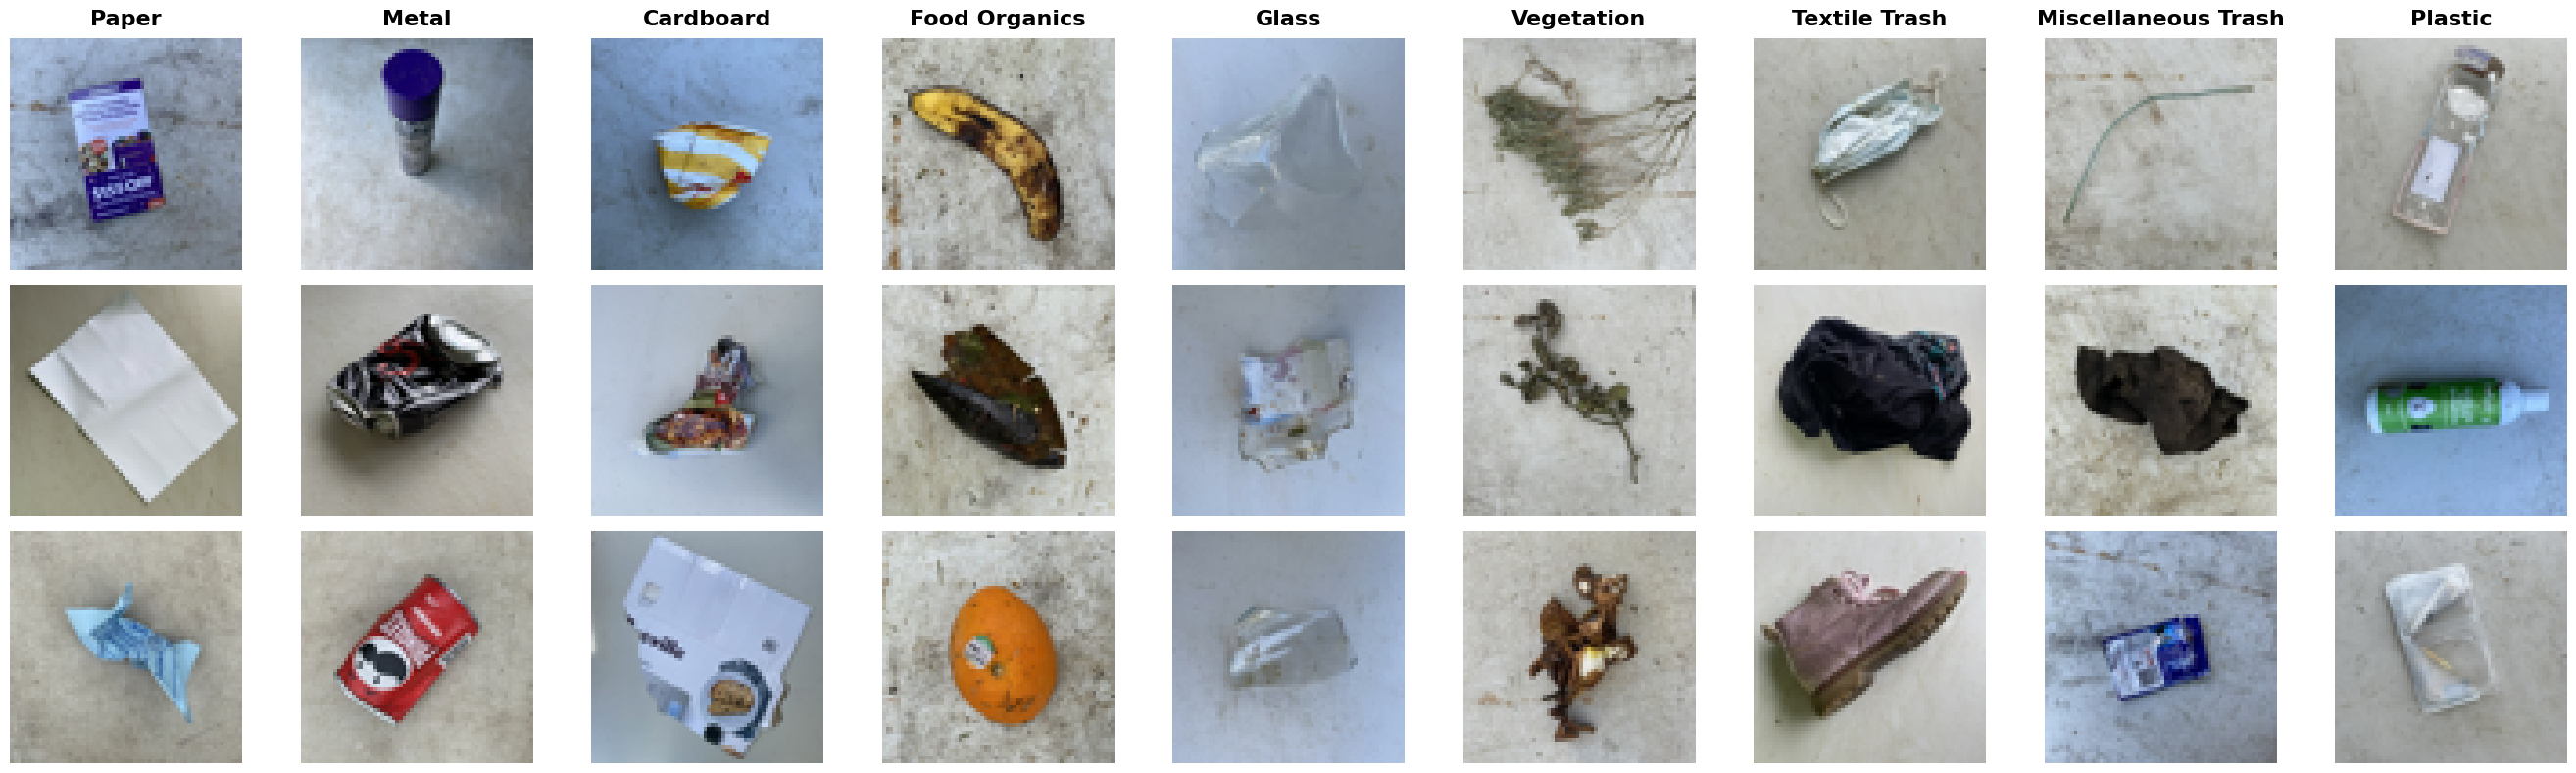

In [9]:
# It plots a grid of images where each col is a class and each row is an image from that class
def plot_imgs_grid_from_array(X, y, class_map, imgs_per_class=3, save_img=False, output_path=""):

    # if input X is flat (1d version) then reshape it to 3D
    if len(X.shape) == 2:
        n_samples, n_features = X.shape
        img_size = int(np.sqrt(n_features // 3))
        X = X.reshape(n_samples, img_size, img_size, 3)

    # invert mapping from class name to index
    inverted_class_map = {index: class_name for class_name, index in class_map.items()}
    class_indices = sorted(np.unique(y))
    n_classes = len(class_indices)

    # create imgs_dict 
    imgs_dict = {inverted_class_map[index]: X[y == index] for index in class_indices}

    # set the fig size based on the number of classes and images per class
    plt.figure(figsize=(imgs_per_class * n_classes, 8))

    # for each class, get random images and insert them in the grid
    for col_n, (class_name, images) in enumerate(imgs_dict.items()):
        if len(images) == 0:
            continue
        
        # get random images from that class
        random_images = random.sample(list(images), min(imgs_per_class, len(images)))

        for row_n, image in enumerate(random_images):
            if isinstance(image, tf.Tensor):
                img = img.numpy()
            img = np.clip(image, 0.0, 1.0)  # safety
            grid_pos = row_n * n_classes + col_n + 1

            plt.subplot(imgs_per_class, n_classes, grid_pos)
            plt.imshow(image)
            if row_n == 0:
                plt.title(class_name, fontsize=16, fontweight='bold', pad=10)
            plt.axis('off')

    plt.tight_layout()

    if save_img:
        plt.savefig(output_path, format='jpg')
        print(f"Grid of images saved to {output_path}")

    plt.show()

plot_imgs_grid_from_array(X_svm, y, class_map, imgs_per_class=3)

In [34]:
splits_dataset_path = "np_data/waste_data_splits.npz"
if os.path.exists(splits_dataset_path):
    print("Loading data splits from {split_dataset_path}")
    splits_data = np.load(splits_dataset_path)
    X_cnn_train = splits_data['X_cnn_train']
    X_cnn_val = splits_data['X_cnn_val']
    X_cnn_test = splits_data['X_cnn_test']
    X_svm_train = splits_data['X_svm_train']
    X_svm_val = splits_data['X_svm_val']
    X_svm_test = splits_data['X_svm_test']
    y_train = splits_data['y_train']
    y_val = splits_data['y_val']
    y_test = splits_data['y_test']

else:
    print("Creating data splits...")
    # Split the data into CNN and SVM versions of training, validation and test sets using indices
    indices = np.arange(len(y))
    train_val_indices, test_indices = train_test_split(indices, test_size=0.2, stratify=y, random_state=42)
    train_indices, val_indices = train_test_split(train_val_indices, test_size=0.2, stratify=y[train_val_indices], random_state=42)

    X_cnn_train, X_cnn_val, X_cnn_test = X_cnn[train_indices], X_cnn[val_indices], X_cnn[test_indices]
    X_svm_train, X_svm_val, X_svm_test = X_svm[train_indices], X_svm[val_indices], X_svm[test_indices]
    y_train, y_val, y_test = y[train_indices], y[val_indices], y[test_indices]
    print("Data has been created")

    # save the splits dataset
    # np.savez(splits_dataset_path, X_cnn_train=X_cnn_train, X_cnn_val=X_cnn_val, X_cnn_test=X_cnn_test, X_svm_train=X_svm_train, X_svm_val=X_svm_val, X_svm_test=X_svm_test, y_train=y_train, y_val=y_val, y_test=y_test)

# Summary of the splits
print(f"Train set: {len(X_cnn_train)} images")
print(f"Validation set: {len(X_cnn_val)} images")
print(f"Test set: {len(X_cnn_test)} images")

Creating data splits...
Data has been created
Train set: 3040 images
Validation set: 761 images
Test set: 951 images


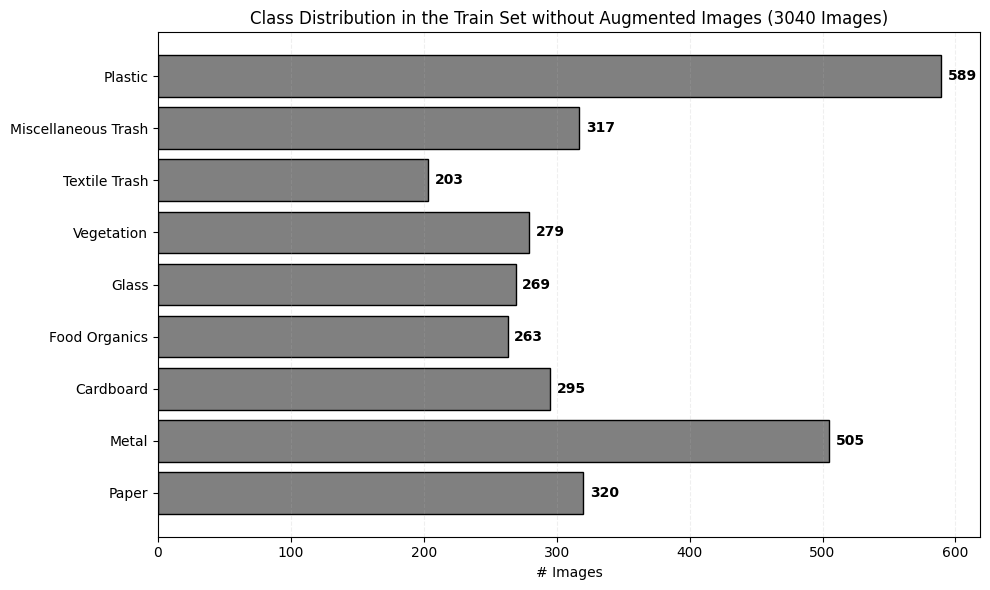

In [ ]:
# visualize class distribution in the train set
plot_class_distribution(y_labels= y_train, class_map=class_map, title="Class Distribution in the Train Set without Augmented Images")

In [13]:
# It takes an image in 3D format and performs data augmentation on it
def augment_image(image):
    # convert the image to a tensor
    image = tf.convert_to_tensor(image, dtype=tf.float32)

    # random horizontal and vertical flip
    image= tf.image.random_flip_left_right(image)
    image= tf.image.random_flip_up_down(image)

    # random 90 degree multiples rotation
    k= tf.random.uniform([], minval=0, maxval=4, dtype=tf.int32)
    image= tf.image.rot90(image, k)

    # random brightness
    image= tf.image.random_brightness(image, max_delta=0.2)

    # random contrast
    image= tf.image.random_contrast(image, lower=0.8, upper=1.2)

    # random saturation
    image= tf.image.random_saturation(image, lower=0.8, upper=1.2)

    # random hue
    image= tf.image.random_hue(image, max_delta=0.05)

    # random gaussin noise
    noise= tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=0.03, dtype=tf.float32)
    image = tf.clip_by_value(image + noise, 0.0, 1.0)

    # return the image as a numpy array
    return image.numpy()

# It takes a list of images in 3D format and a list of labels and returns a balanced dataset with a number of images per class = target_size_per_class
# To increase the size of the dataset, the function performs data augmentation on the images
def dataset_augmentation_to_target(X_train, y_train, target_size_per_class= 600):
    X_augmented, y_augmented= [], []

    # number of classes
    unique_classes = np.unique(y_train)
    
    # iterate through each class
    for cls in unique_classes:
        X_class = X_train[y_train == cls] # images of that class
        n_images = len(X_class) # n images of the class
        n_needed = target_size_per_class - n_images # n images needed to reach target_size_per_class

        if n_needed <= 0:
            continue # if the class has more images than the target than skip it
        
        for _ in tqdm(range(n_needed), desc=f"Augmenting class {cls}") : # for each image needed
            # get a random image from the class
            random_image = X_class[np.random.randint(0, n_images)]
            # augment the image
            augmented_image = augment_image(random_image)
            # append the image and label to the lists
            X_augmented.append(augmented_image)
            y_augmented.append(cls)

    # concatenate the original images with the augmented images
    X_balanced = np.concatenate((X_train, np.array(X_augmented)), axis=0)
    y_balanced = np.concatenate((y_train, np.array(y_augmented)), axis=0)
    print(f"Augmented {len(X_augmented)} images \n")

    # return the balanced dataset
    return X_balanced, y_balanced

balanced_dataset_path = "np_data/balanced_dataset_size128_images600.npz"
if os.path.exists(balanced_dataset_path):
    print("Loading augmented dataset from {balanced_dataset_path}")
    balanced_dataset = np.load(balanced_dataset_path)
    X_cnn_train_balanced = balanced_dataset['X_cnn_train_balanced']
    y_train_balanced = balanced_dataset['y_train_balanced']
else:
    print("Creating augmented dataset...")
    X_cnn_train_balanced, y_train_balanced = dataset_augmentation_to_target(X_cnn_train, y_train, target_size_per_class=600)
    print("Augmented dataset has been created")

    # save the augmented dataset
    # np.savez_compressed(balanced_dataset_path, X_cnn_train_balanced=X_cnn_train_balanced, y_train_balanced=y_train_balanced)

Loading augmented dataset from {balanced_dataset_path}


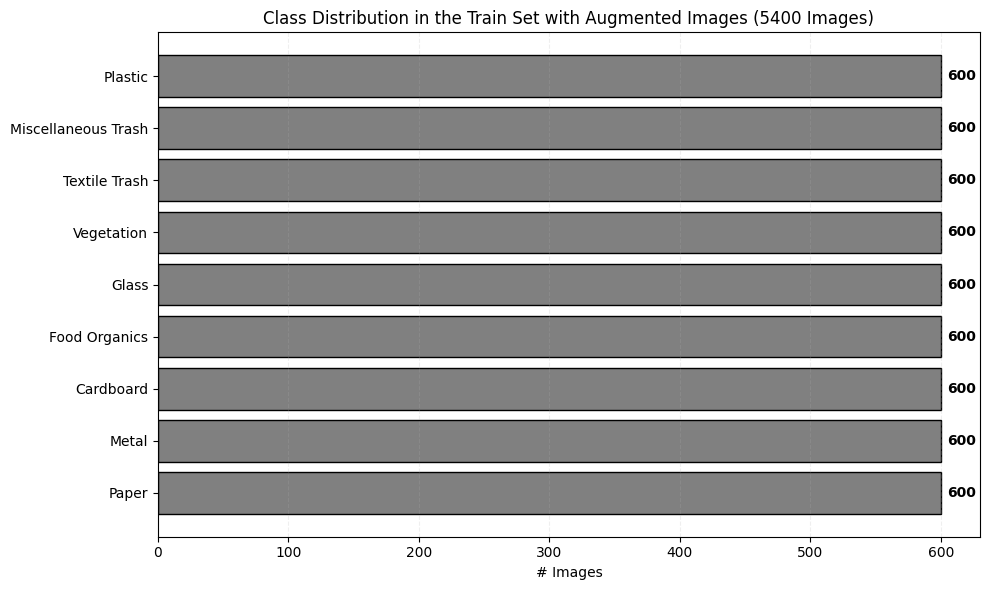

In [14]:
# Verify the class distribution in the augmented dataset
plot_class_distribution(y_labels= y_train_balanced, class_map=class_map, title="Class Distribution in the Train Set with Augmented Images")

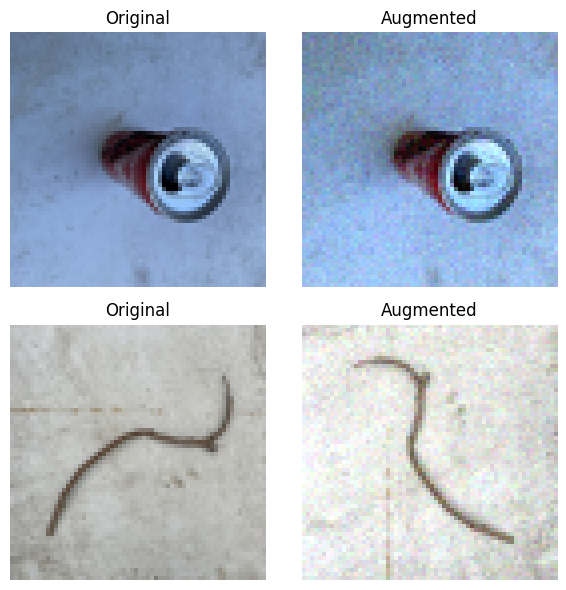

In [13]:
def visualize_augmentation_effects(X, n_images= 2):
    random_indices = np.random.choice(len(X), n_images, replace=False)

    # store the original images and the augmented images
    original_images = X[random_indices]
    augmented_images = [augment_image(image) for image in original_images]

    # create a  n_images x 2 grid with original_images on the first col and augmented_images on the second col
    plt.figure(figsize=(n_images * 3, 6))

    for i in range(n_images):
        # plot original images
        plt.subplot(n_images, 2, i * 2 + 1)
        plt.imshow(np.clip(original_images[i], 0.0, 1.0))
        plt.title("Original")
        plt.axis('off')

        # plot augmented images
        plt.subplot(n_images, 2, i * 2 + 2)
        plt.imshow(np.clip(augmented_images[i], 0.0, 1.0))
        plt.title("Augmented")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

visualize_augmentation_effects(X_cnn_train, n_images= 2)

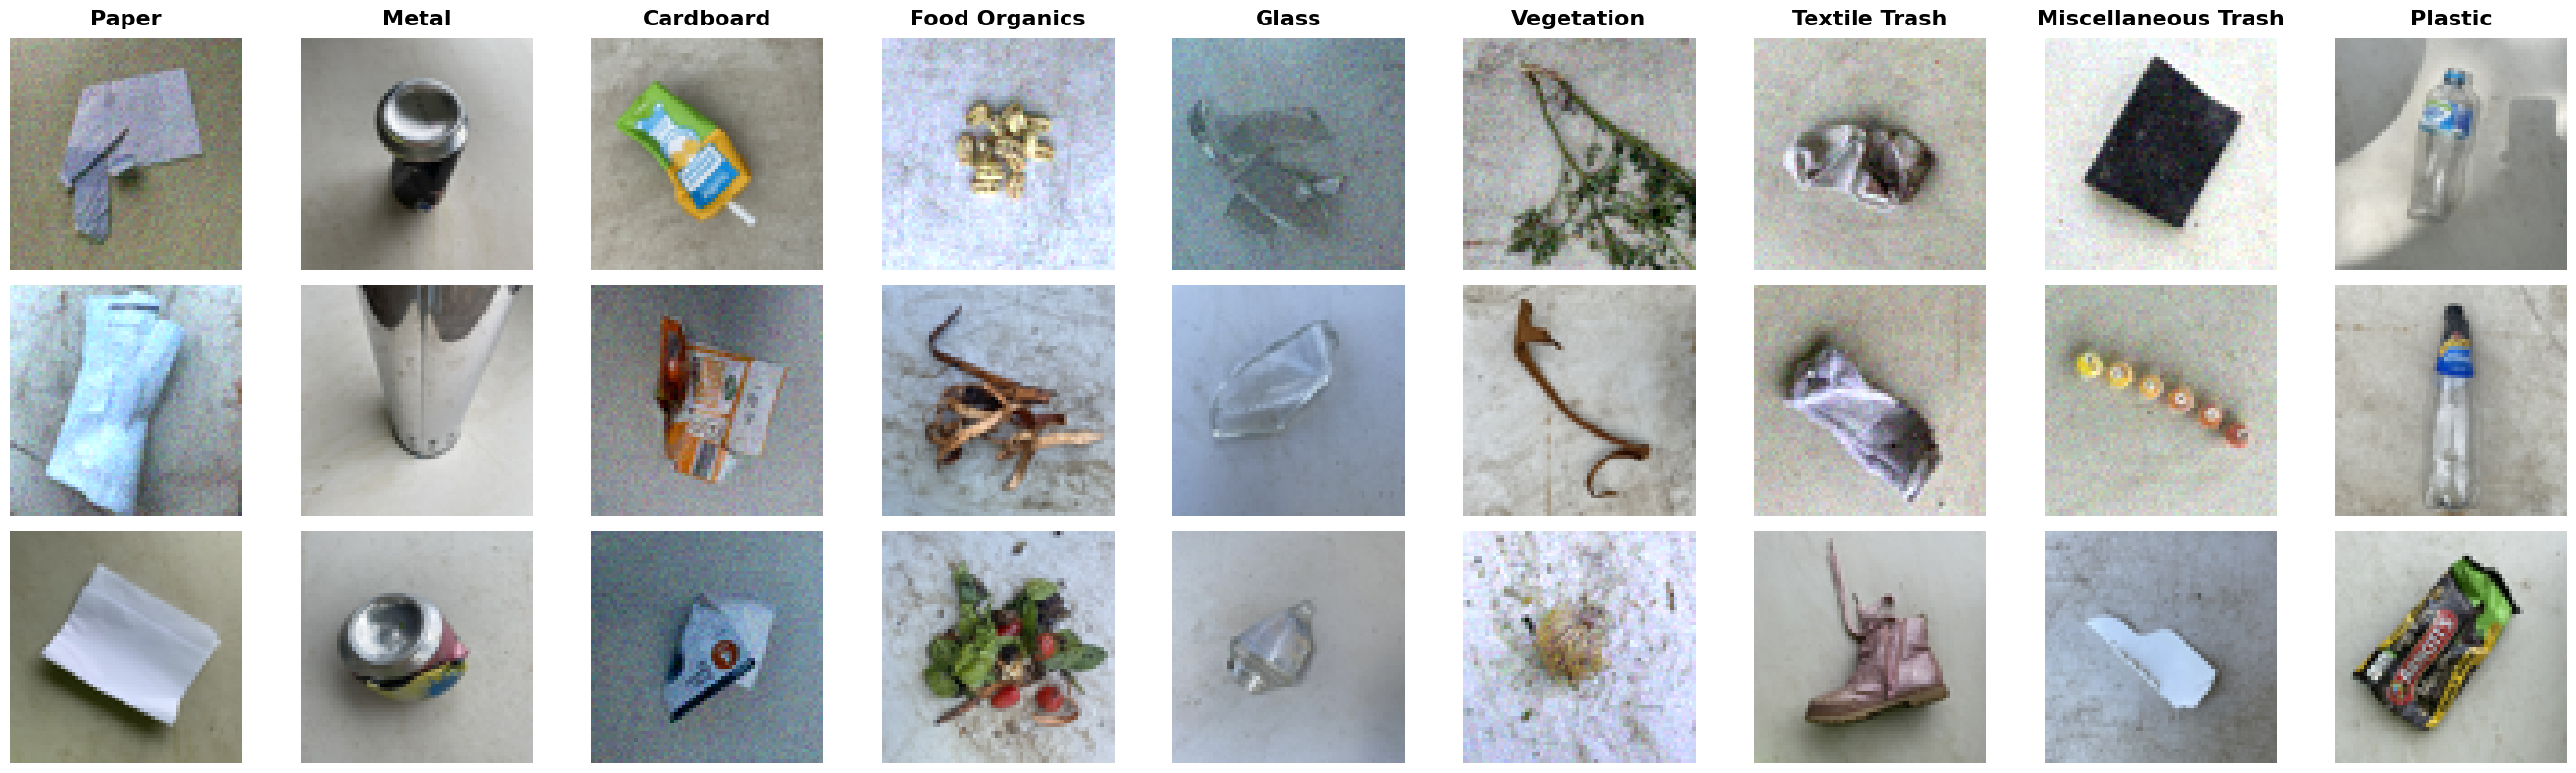

In [14]:
# Show a sample of images after augmentation
plot_imgs_grid_from_array(X_cnn_train_balanced, y_train_balanced, class_map, imgs_per_class=3)

In [36]:
# It computes the image distribution among the classes in the train, validation and test sets
def get_class_distribution_table(y_train, y_val, y_test, class_map, y_train_balanced=None):
    # invert the class map in order to get from class index to class name
    inv_class_map = {i: c for c, i in class_map.items()}

    # count n images in each set
    train_class_distribution = Counter(y_train)
    val_class_distribution = Counter(y_val)
    test_class_distribution = Counter(y_test)

    if y_train_balanced is not None:
        balanced_train_class_distribution = Counter(y_train_balanced) # if the train set is augmented and balanced, count the n images in each class

    data = []
    for index in sorted(inv_class_map.keys()):
        class_name = inv_class_map[index]
        train_size = train_class_distribution.get(index, 0)
        val_size = val_class_distribution.get(index, 0)
        test_size = test_class_distribution.get(index, 0)

        row = {
            "Waste Class": class_name,
            "Train Size": train_size,
            "Validation Size": val_size,
            "Test Size": test_size
        }

        if y_train_balanced is not None:
            balanced_size = balanced_train_class_distribution.get(index, 0)
            n_augmented = balanced_size - train_size
            perc_aug = (n_augmented / balanced_size * 100) if balanced_size > 0 else 0
            row["Train Size"] = balanced_size
            row["% Augmented in Train Set"] = round(perc_aug, 1)

        data.append(row)

    df = pd.DataFrame(data)
    return df

# Show the class distribution in the train, validation and test sets
print("Class distribution in the train, validation and test sets without augmentation:")
get_class_distribution_table(y_train, y_val, y_test, class_map)

Class distribution in the train, validation and test sets without augmentation:


,Waste Class,Train Size,Validation Size,Test Size
0,Paper,320,80,100
1,Metal,505,127,158
2,Cardboard,295,74,92
3,Food Organics,263,66,82
4,Glass,269,67,84
5,Vegetation,279,70,87
6,Textile Trash,203,51,64
7,Miscellaneous Trash,317,79,99
8,Plastic,589,147,185


In [16]:
print("\n Class distribution in the train, validation and test sets with augmentation:")
get_class_distribution_table(y_train, y_val, y_test, class_map, y_train_balanced)


 Class distribution in the train, validation and test sets with augmentation:


,Waste Class,Train Size,Validation Size,Test Size,% Augmented in Train Set
0,Paper,600,80,100,46.7
1,Metal,600,127,158,15.8
2,Cardboard,600,74,92,50.8
3,Food Organics,600,66,82,56.2
4,Glass,600,67,84,55.2
5,Vegetation,600,70,87,53.5
6,Textile Trash,600,51,64,66.2
7,Miscellaneous Trash,600,79,99,47.2
8,Plastic,600,147,185,1.8


# SVM Classifier - Training and Evaluation with the Original Dataset

In the following section we build and evaluate our first waste image classifier using a Support Vector Machine Algorithm. This model will be used as baseline model and will be compared to the CNN which will be trained in future sections. 

Steps:
1. Make sure that the input shape is compatible with the SVM algorithm
2. Define the SVM pipeline: we normalize the data, we use PCA to reduce the dimensionality of the data and then we fit a SVM with `class_weight='balanced' to manage the class imbalance.
3. We look for the best hyper-parameters to use implementing a Grid Search CV
4. We evaluate the performance of the best SVM model using a combination of the validation and test set
5. We visualize the results using a confusion matrix
6. We print some sample predictions with the corresponding predicted probabilities

In [18]:
# Check whether X_svm_train, X_svm_val and X_svm_test are compatible with SVM
print("X_svm_train shape:", X_svm_train.shape)
print("y_train shape:", y_train.shape)

print("X_svm_val shape:", X_svm_val.shape)
print("y_val shape:", y_val.shape)

print("X_svm_test shape:", X_svm_test.shape)
print("y_test shape:", y_test.shape)
# (x, y) where x is the number of images and y is the number of elements in the flattened array representation of the image

X_svm_train shape: (3040, 12288)
y_train shape: (3040,)
X_svm_val shape: (761, 12288)
y_val shape: (761,)
X_svm_test shape: (951, 12288)
y_test shape: (951,)


In [19]:
# First array in X_svm_train
print("First image in X_svm_train array:", X_svm_train[0])

First image in X_svm_train array: [0.65882353 0.63529412 0.58823529 ... 0.74509804 0.72156863 0.64313725]


In [21]:
# define the SVM pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()), # scale the data
    ('pca', PCA(n_components=0.90)), # PCA to reduce dimensionality by selecting the components that explain 90% of the variance
    ('svc', SVC(class_weight='balanced', probability= True, random_state= SEED)) # SVC with balanced class weights (because the dataset is imbalanced)
])

# define the parameter grid for the SVM
param_grid = {
    'svc__C': [0.01, 0.1, 1, 10],
    'svc__gamma': ['scale', 0.0001, 0.00001],
    'svc__kernel': ['rbf']
}

# number of combinations
n_combinations = len(list(product(param_grid['svc__C'], param_grid['svc__gamma'], param_grid['svc__kernel'])))
cv_folds = 3
total_n_fits = n_combinations * cv_folds

# perform a grid search to find the best parameters for the SVM
start_time = time.time()
gridsearch = GridSearchCV(pipeline, param_grid, cv=3, scoring='accuracy', verbose=2)
gridsearch.fit(X_svm_train, y_train)
end_time = time.time()

# time taken
svm_total_time = end_time - start_time
svm_avg_time_per_fit = svm_total_time / total_n_fits
print(f"\nTotal time taken: {svm_total_time:.2f} seconds for {total_n_fits} fits")
print(f"Average time per fit: {svm_avg_time_per_fit:.2f} seconds\n")

# print the best parameters
print("Best parameters:", gridsearch.best_params_)
print("Validation+Test set Accuracy:", gridsearch.best_score_)


Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV] END .....svc__C=0.01, svc__gamma=scale, svc__kernel=rbf; total time=   9.5s
[CV] END .....svc__C=0.01, svc__gamma=scale, svc__kernel=rbf; total time=   9.1s
[CV] END .....svc__C=0.01, svc__gamma=scale, svc__kernel=rbf; total time=   9.4s
[CV] END ....svc__C=0.01, svc__gamma=0.0001, svc__kernel=rbf; total time=   9.2s
[CV] END ....svc__C=0.01, svc__gamma=0.0001, svc__kernel=rbf; total time=   9.5s
[CV] END ....svc__C=0.01, svc__gamma=0.0001, svc__kernel=rbf; total time=   9.1s
[CV] END .....svc__C=0.01, svc__gamma=1e-05, svc__kernel=rbf; total time=   9.1s
[CV] END .....svc__C=0.01, svc__gamma=1e-05, svc__kernel=rbf; total time=   9.3s
[CV] END .....svc__C=0.01, svc__gamma=1e-05, svc__kernel=rbf; total time=   9.2s
[CV] END ......svc__C=0.1, svc__gamma=scale, svc__kernel=rbf; total time=   8.7s
[CV] END ......svc__C=0.1, svc__gamma=scale, svc__kernel=rbf; total time=   8.9s
[CV] END ......svc__C=0.1, svc__gamma=scale, svc

In [26]:
# concatenate the validation and test sets to evaluate the performance of the best SVM model
X_svm_val_test = np.concatenate((X_svm_val, X_svm_test), axis=0)
y_val_test = np.concatenate((y_val, y_test), axis=0)

# performance of the best SVM model on the valid + test sets
best_svm_model = gridsearch.best_estimator_
y_val_test_pred = best_svm_model.predict(X_svm_val_test)

print("Accuracy on Val + Test set (New SVM):", round(accuracy_score(y_val_test, y_val_test_pred), 2))
print(classification_report(y_val_test, y_val_test_pred))

Accuracy on Val + Test set (New SVM): 0.66
              precision    recall  f1-score   support

           0       0.76      0.75      0.75       180
           1       0.63      0.70      0.66       285
           2       0.74      0.67      0.70       166
           3       0.75      0.66      0.70       148
           4       0.72      0.80      0.76       151
           5       0.61      0.78      0.68       157
           6       0.56      0.50      0.53       115
           7       0.49      0.40      0.44       178
           8       0.68      0.66      0.67       332

    accuracy                           0.66      1712
   macro avg       0.66      0.66      0.66      1712
weighted avg       0.66      0.66      0.66      1712



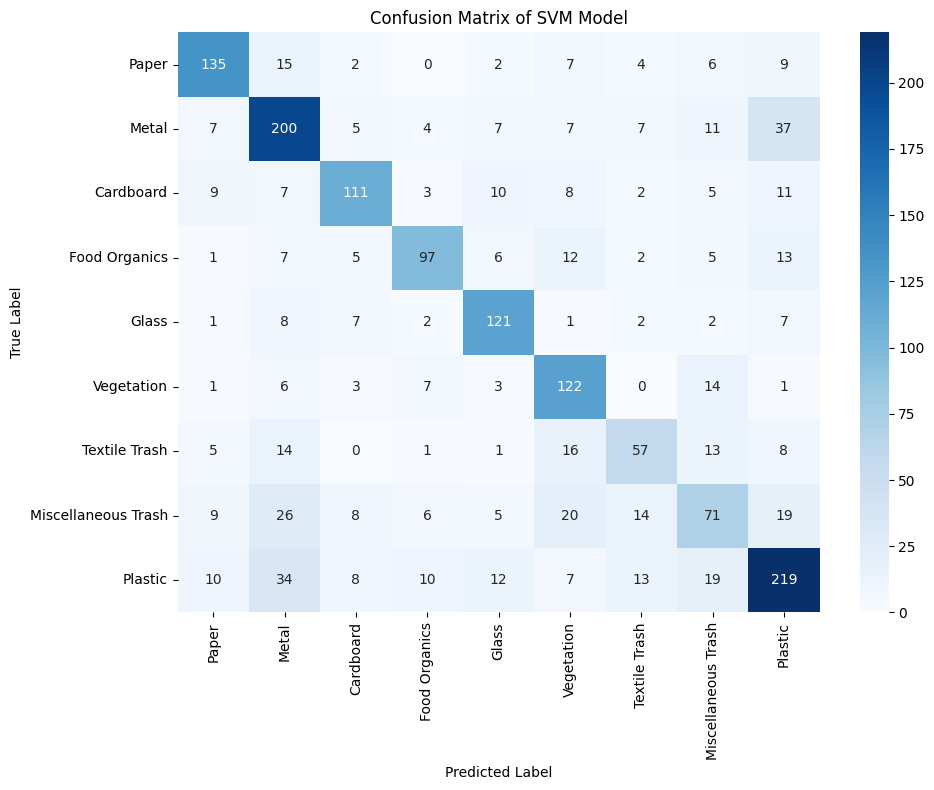

In [29]:
# It plots the confusion matrix for the given predictions and true labels
def plot_confusion_matrix(y_true, y_pred, class_map, title= "Confusion Matrix of "):
    cm = confusion_matrix(y_true, y_pred)

    # invert the class map in order to get from class index to class name
    inv_class_map = {v: k for k, v in class_map.items()}
    labels = [inv_class_map[i] for i in sorted(inv_class_map.keys())]

    # plot the matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(title)
    plt.xticks()
    plt.yticks()
    plt.tight_layout()
    plt.show()

# Plot a confusion matrix for the SVM model
plot_confusion_matrix(y_val_test, y_val_test_pred, class_map, title= "Confusion Matrix of SVM Model")

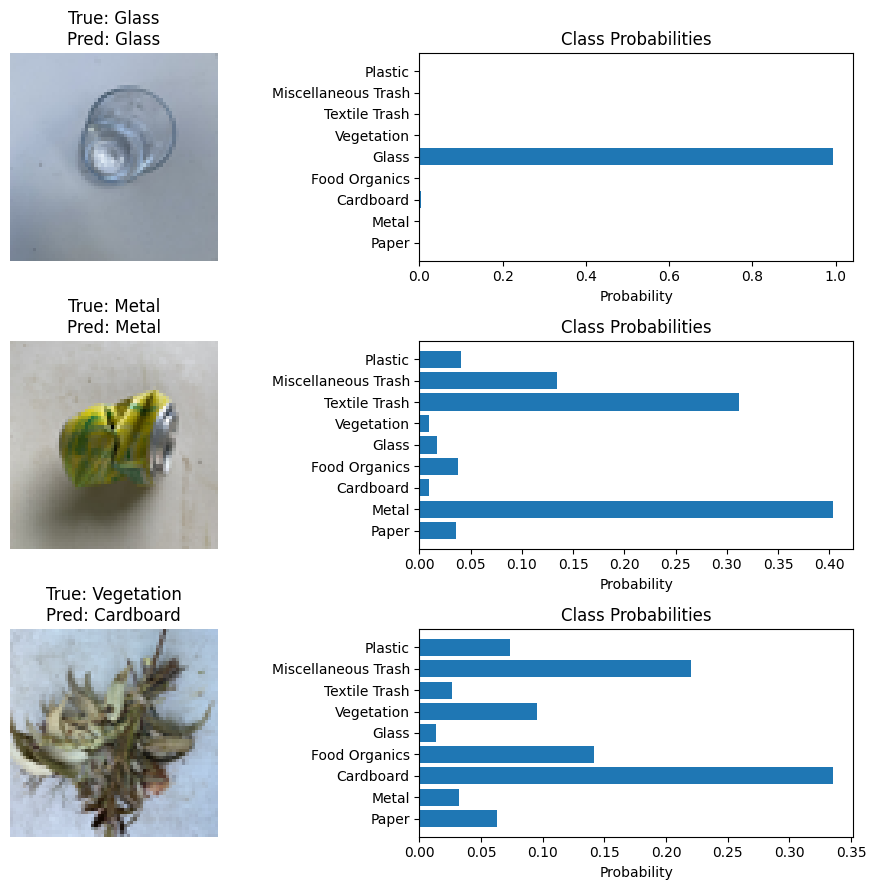

In [30]:
# Plot of 3 images with their predicted probabilities
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
random.seed(42)

inv_class_map = {v: k for k, v in class_map.items()}
for i in range(3):
    # select 3 random images from the test set
    random_idx = random.randint(0, len(X_svm_test) - 1)
    x_sample = X_svm_test[random_idx].reshape(1, -1)
    y_true = y_test[random_idx]

    # make predictions using the best SVM model
    probs = best_svm_model.predict_proba(x_sample)[0]
    y_pred = np.argmax(probs)

    # reshape the image to 3D format
    img = (x_sample.reshape(64, 64, 3) * 255).astype(np.uint8)

    # plot the image
    axes[i, 0].imshow(img)
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"True: {inv_class_map[y_true]}\nPred: {inv_class_map[y_pred]}")

    # plot the predicted probabilities
    class_labels = [inv_class_map[j] for j in range(len(probs))]
    axes[i, 1].barh(class_labels, probs)
    axes[i, 1].set_xlabel("Probability")
    axes[i, 1].set_title("Class Probabilities")

plt.tight_layout()
plt.show()


# Convolutional Neural Network - Training and Evaluation with the Original Dataset

In the following section we build and evaluate our first Convolutional Neural Network classifier using the non augmented training data. 

Steps:
1. Make sure that the input shape is compatible with the CNN algorithm
2. Build a function to create different CNN architectures with tunable hyperparameters.
3. We tried different values for the learning rate, dropout, for the dense units based on our analysis of the training and valuation performance over the epochs
4. We chose 1 "best" model among these CNNs
5. We then analyzed the performance metrics on the test set, we plotted the classification report, the confusion matrix and then 3 images from the test set with their predictions

In [34]:
# check whether X_cnn_train, X_cnn_val and X_cnn_test are compatible with CNN
print("X_cnn_train shape:", X_cnn_train.shape)
print("y_train shape:", y_train.shape)

print("X_cnn_val shape:", X_cnn_val.shape)
print("y_val shape:", y_val.shape)

print("X_cnn_test shape:", X_cnn_test.shape)
print("y_test shape:", y_test.shape)
# (n, x, y, z) where n is the number of images and x, y is the image dimension and z is the number of channels (RGB)

X_cnn_train shape: (3040, 64, 64, 3)
y_train shape: (3040,)
X_cnn_val shape: (761, 64, 64, 3)
y_val shape: (761,)
X_cnn_test shape: (951, 64, 64, 3)
y_test shape: (951,)


In [35]:
# first 3d array in X_cnn_train
print("First image in X_cnn_train:", X_cnn_train[0])

First image in X_cnn_train: [[[0.65882353 0.63529412 0.58823529]
  [0.65882353 0.63921569 0.59215686]
  [0.66666667 0.65098039 0.60392157]
  ...
  [0.70980392 0.69803922 0.6627451 ]
  [0.71372549 0.69803922 0.6627451 ]
  [0.72156863 0.70980392 0.66666667]]

 [[0.6627451  0.63529412 0.58823529]
  [0.66666667 0.64705882 0.6       ]
  [0.6627451  0.64705882 0.6       ]
  ...
  [0.70980392 0.69803922 0.6627451 ]
  [0.7254902  0.70980392 0.6745098 ]
  [0.71764706 0.70588235 0.67058824]]

 [[0.66666667 0.63921569 0.59215686]
  [0.66666667 0.64705882 0.6       ]
  [0.6627451  0.64313725 0.59607843]
  ...
  [0.71764706 0.70588235 0.67058824]
  [0.71764706 0.70588235 0.67058824]
  [0.7254902  0.71372549 0.67843137]]

 ...

 [[0.70588235 0.68235294 0.63137255]
  [0.70196078 0.67843137 0.62352941]
  [0.69803922 0.6745098  0.61568627]
  ...
  [0.74509804 0.71372549 0.66666667]
  [0.74901961 0.72156863 0.67058824]
  [0.74901961 0.72941176 0.66666667]]

 [[0.72156863 0.69803922 0.64705882]
  [0.7137

In [41]:
# shape of the input
cnn_input_shape = X_cnn_train.shape[1:]
# number of unique waste classes
num_classes = len(np.unique(y_train))

# Given some hyperparameters, it creates a CNN model
def create_cnn_model(cnn_input_shape, num_classes, initial_filters, dense_units, dropout_rate):
    #define the model structure
    model = Sequential([
    # first convolutional layer
    Conv2D(initial_filters, (3, 3), padding='same', input_shape=cnn_input_shape),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),
    
    # second convolutional layer
    Conv2D(initial_filters*2 , (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    # third convolutional layer
    Conv2D(initial_filters*4 , (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(dense_units),
    BatchNormalization(),
    Activation('relu'),
    Dropout(dropout_rate),
    Dense(num_classes, activation='softmax')
    ])

    return model

# It takes a model's history and plots the training and validation accuracy and loss over epochs
def plot_model_history_metrics(history, title= "", model_parameters= None, training_time= None, save_img= False):
    # metrics to plot
    acc= history.history['accuracy']
    val_acc= history.history['val_accuracy']
    loss= history.history['loss']
    val_loss= history.history['val_loss']
    epochs= range(1, len(acc)+1)

    # set a style for the plot
    plt.style.use('ggplot') 

    # plot history
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, label='Train', color='#1f77b4', linewidth=2, marker='o')
    plt.plot(epochs, val_acc, label='Val', color='#ff7f0e', linewidth=2, marker='s')
    plt.title('Accuracy')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, label='Train', color='#1f77b4', linewidth=2, marker='o')
    plt.plot(epochs, val_loss, label='Val', color='#ff7f0e', linewidth=2, marker='s')
    plt.title('Loss')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.4)

    if title:
        plt.suptitle(title, fontsize=16, fontweight='bold')
        subtitle= ""
        if model_parameters is not None:
            subtitle += f"Params: {model_parameters}  "
        if training_time is not None:
            subtitle += f" | Training time: {training_time:.2f} sec"
        # add subtitle with figtext under the title
        if subtitle:
            plt.figtext(0.5, 0.87, subtitle, wrap=True, horizontalalignment='center', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.90])

    if save_img == True and title != "":
        plt.savefig(f"{title}.png", format='png')

    plt.show()
    return

# Creates a function that takes the hyperparameters and the training and validation sets and returns a model and its history
def create_fit_cnn_model(cnn_input_shape, num_classes, initial_filters, dense_units, dropout_rate, learning_rate, batch_size, num_epochs, X_train, y_train, X_val, y_val):
    # create the first CNN model for the not augmented dataset
    model= create_cnn_model(cnn_input_shape= cnn_input_shape, num_classes= num_classes, initial_filters= initial_filters, dense_units= dense_units, dropout_rate= dropout_rate)

    # compile the model with a specified learning rate
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer= optimizer,
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])
    
    # set the callbacks
    callbacks = [
        tf.keras.callbacks.ReduceLROnPlateau(factor=0.3, patience=2),
        tf.keras.callbacks.EarlyStopping(patience=5,
                                         restore_best_weights=True)
    ]

    # train the model
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=num_epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1
    )

    return {"model": model, "history": history}


/Users/ludovicofrancia/Desktop/ML WASTE PRù/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 80ms/step - accuracy: 0.3227 - loss: 2.1087 - val_accuracy: 0.0880 - val_loss: 3.0141 - learning_rate: 5.0000e-04
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 80ms/step - accuracy: 0.5467 - loss: 1.3461 - val_accuracy: 0.1419 - val_loss: 4.5291 - learning_rate: 5.0000e-04
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.6241 - loss: 1.1109 - val_accuracy: 0.1774 - val_loss: 4.5993 - learning_rate: 5.0000e-04
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7050 - loss: 0.9169 - val_accuracy: 0.2878 - val_loss: 3.8273 - learning_rate: 1.5000e-04
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.7548 - loss: 0.7818 - val_accuracy: 0.3351 - val_loss: 2.6379 - learning_rate: 1.5000e-04
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.8111 - loss: 0.6934 - val_accuracy: 0.4021 - val_loss: 2.0478 - learning_rate: 1.5000e-04
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.8339 

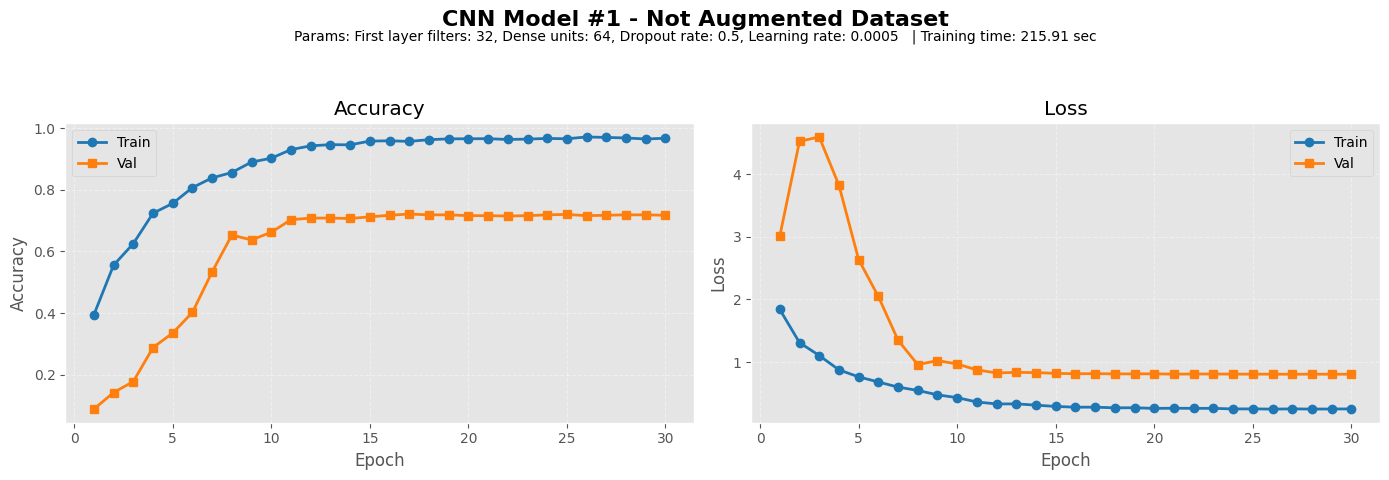

In [37]:
# create and fit the first CNN model on the not augmented dataset with the given hyperparameters
batch_size = 32
num_epochs = 30
learning_rate = 0.0005
initial_filters = 32
dense_units = 64
dropout_rate = 0.5

start_time = time.time()
fitted_model_1= create_fit_cnn_model(cnn_input_shape= cnn_input_shape, num_classes= num_classes, 
                                     initial_filters= initial_filters, dense_units= dense_units, dropout_rate= dropout_rate, 
                                     learning_rate= learning_rate,
                                     batch_size= batch_size, num_epochs= num_epochs,
                                     X_train= X_cnn_train, y_train= y_train, 
                                     X_val= X_cnn_val, y_val= y_val)
end_time = time.time()
cnn_1_training_time = end_time - start_time

plot_model_history_metrics(fitted_model_1["history"], 
                           title= f"CNN Model #1 - Not Augmented Dataset", 
                           model_parameters= f"First layer filters: {initial_filters}, Dense units: {dense_units}, Dropout rate: {dropout_rate}, Learning rate: {learning_rate}",
                           training_time= cnn_1_training_time,
                           save_img= True)

/Users/ludovicofrancia/Desktop/ML WASTE PRù/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 82ms/step - accuracy: 0.2501 - loss: 2.3361 - val_accuracy: 0.1919 - val_loss: 2.3207 - learning_rate: 1.0000e-04
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.4356 - loss: 1.6500 - val_accuracy: 0.0880 - val_loss: 2.4743 - learning_rate: 1.0000e-04
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - accuracy: 0.4919 - loss: 1.4181 - val_accuracy: 0.0880 - val_loss: 2.6898 - learning_rate: 1.0000e-04
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.5501 - loss: 1.3072 - val_accuracy: 0.2089 - val_loss: 2.4052 - learning_rate: 3.0000e-05
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.5709 - loss: 1.2316 - val_accuracy: 0.3193 - val_loss: 1.8819 - learning_rate: 3.0000e-05
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - accuracy: 0.5924 - loss: 1.1634 - val_accuracy: 0.4770 - val_loss: 1.4421 - learning_rate: 3.0000e-05
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 74ms/step - accuracy: 0.6153 

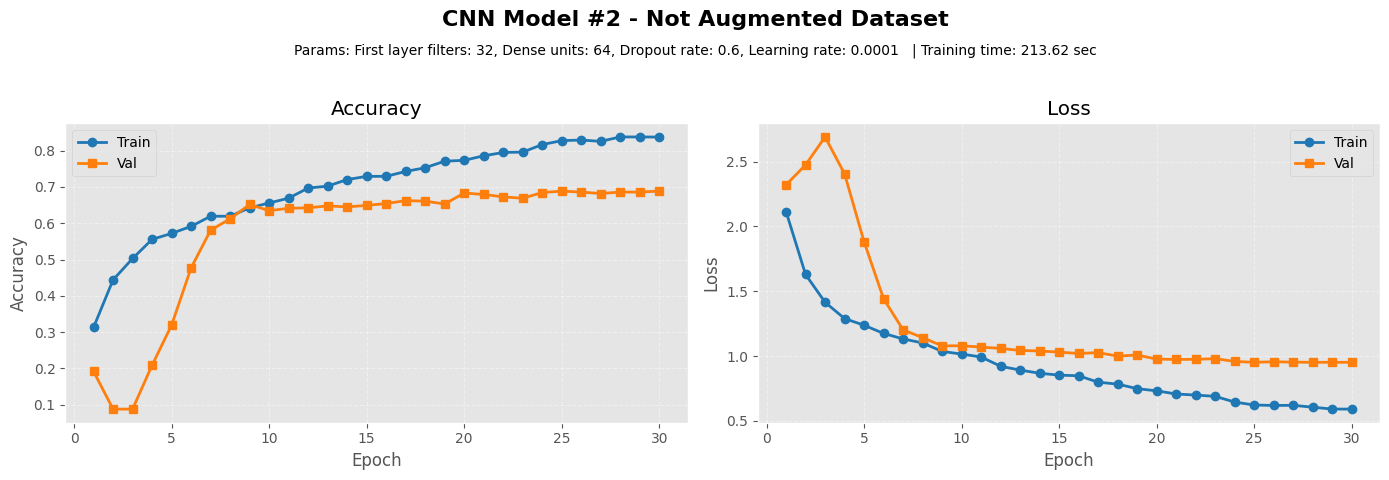

In [40]:
# create and fit a CNN model on the not augmented dataset with the given hyperparameters
batch_size = 32
num_epochs = 30
learning_rate = 0.0001
initial_filters = 32
dense_units = 64
dropout_rate = 0.6

start_time = time.time()
fitted_model_2= create_fit_cnn_model(cnn_input_shape= cnn_input_shape, num_classes= num_classes, 
                                     initial_filters= initial_filters, dense_units= dense_units, dropout_rate= dropout_rate, 
                                     learning_rate= learning_rate,
                                     batch_size= batch_size, num_epochs= num_epochs,
                                     X_train= X_cnn_train, y_train= y_train, 
                                     X_val= X_cnn_val, y_val= y_val)
end_time = time.time()
cnn_2_training_time = end_time - start_time

plot_model_history_metrics(fitted_model_2["history"], 
                           title= f"CNN Model #2 - Not Augmented Dataset", 
                           model_parameters= f"First layer filters: {initial_filters}, Dense units: {dense_units}, Dropout rate: {dropout_rate}, Learning rate: {learning_rate}",
                           training_time= cnn_2_training_time,
                           save_img= True)

Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 72ms/step - accuracy: 0.1626 - loss: 2.6873 - val_accuracy: 0.0959 - val_loss: 2.2578 - learning_rate: 1.0000e-04
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 70ms/step - accuracy: 0.3016 - loss: 2.0208 - val_accuracy: 0.0880 - val_loss: 2.4412 - learning_rate: 1.0000e-04
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.3676 - loss: 1.8024 - val_accuracy: 0.0933 - val_loss: 2.5040 - learning_rate: 1.0000e-04
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.4008 - loss: 1.6763 - val_accuracy: 0.1340 - val_loss: 2.3177 - learning_rate: 3.0000e-05
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.4271 - loss: 1.6194 - val_accuracy: 0.2681 - val_loss: 1.9631 - learning_rate: 3.0000e-05
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - accuracy: 0.4305 - loss: 1.5597 - val_accuracy: 0.4849 - val_loss: 1.5695 - learning_rate: 3.0000e-05
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step - accuracy: 0.4631 

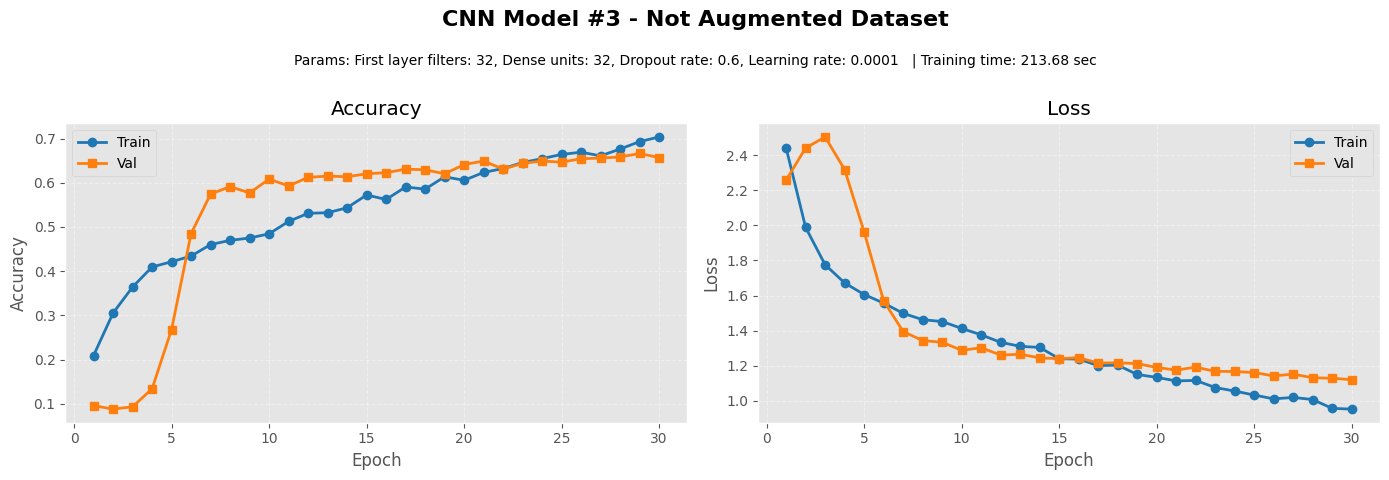

In [44]:
# create and fit a CNN model on the not augmented dataset with the given hyperparameters
batch_size = 32
num_epochs = 30
learning_rate = 0.0001
initial_filters = 32
dense_units = 32
dropout_rate = 0.6

start_time = time.time()
fitted_model_3= create_fit_cnn_model(cnn_input_shape= cnn_input_shape, num_classes= num_classes, 
                                     initial_filters= initial_filters, dense_units= dense_units, dropout_rate= dropout_rate, 
                                     learning_rate= learning_rate,
                                     batch_size= batch_size, num_epochs= num_epochs,
                                     X_train= X_cnn_train, y_train= y_train, 
                                     X_val= X_cnn_val, y_val= y_val)
end_time = time.time()
cnn_3_training_time = end_time - start_time

plot_model_history_metrics(fitted_model_3["history"], 
                           title= f"CNN Model #3 - Not Augmented Dataset", 
                           model_parameters= f"First layer filters: {initial_filters}, Dense units: {dense_units}, Dropout rate: {dropout_rate}, Learning rate: {learning_rate}",
                           training_time= cnn_3_training_time,
                           save_img= True)

/Users/ludovicofrancia/Desktop/ML WASTE PRù/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.1779 - loss: 2.6080 - val_accuracy: 0.0880 - val_loss: 2.5833 - learning_rate: 5.0000e-05
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.2977 - loss: 2.0391 - val_accuracy: 0.0880 - val_loss: 3.2072 - learning_rate: 5.0000e-05
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.3441 - loss: 1.8977 - val_accuracy: 0.0920 - val_loss: 3.2260 - learning_rate: 5.0000e-05
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.3767 - loss: 1.7680 - val_accuracy: 0.1222 - val_loss: 2.8899 - learning_rate: 1.5000e-05
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 82ms/step - accuracy: 0.3802 - loss: 1.7215 - val_accuracy: 0.1905 - val_loss: 2.3147 - learning_rate: 1.5000e-05
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 79ms/step - accuracy: 0.4080 - loss: 1.7061 - val_accuracy: 0.3390 - val_loss: 1.7981 - learning_rate: 1.5000e-05
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - accuracy: 0.4174 

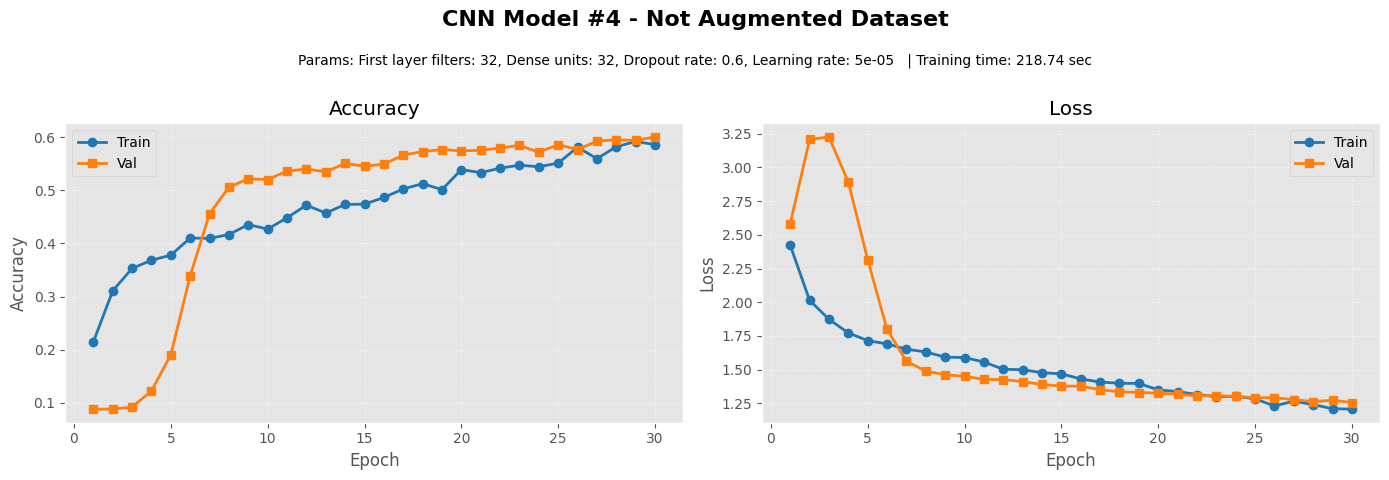

In [79]:
# create and fit a CNN model on the not augmented dataset with the given hyperparameters
batch_size = 32
num_epochs = 30
learning_rate = 0.00005
initial_filters = 32
dense_units = 32
dropout_rate = 0.6

start_time = time.time()
fitted_model_4= create_fit_cnn_model(cnn_input_shape= cnn_input_shape, num_classes= num_classes, 
                                     initial_filters= initial_filters, dense_units= dense_units, dropout_rate= dropout_rate, 
                                     learning_rate= learning_rate,
                                     batch_size= batch_size, num_epochs= num_epochs,
                                     X_train= X_cnn_train, y_train= y_train, 
                                     X_val= X_cnn_val, y_val= y_val)
end_time = time.time()
cnn_4_training_time = end_time - start_time

plot_model_history_metrics(fitted_model_4["history"], 
                           title= f"CNN Model #4 - Not Augmented Dataset", 
                           model_parameters= f"First layer filters: {initial_filters}, Dense units: {dense_units}, Dropout rate: {dropout_rate}, Learning rate: {learning_rate}",
                           training_time= cnn_4_training_time,
                           save_img= True)

In [80]:
# print the structure of the model that has the best performances
best_cnn_model= fitted_model_4["model"]
best_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,069,213 (4.08 MB)

 Trainable params: 356,233 (1.36 MB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 712,468 (2.72 MB)

In [81]:
# predictions using the best model
y_test_pred = best_cnn_model.predict(X_cnn_test)
y_test_pred = np.argmax(y_test_pred, axis=1) # get the class with the highest probability

# classification report
print(classification_report(y_test, y_test_pred, target_names=list(class_map.keys())))

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step
                     precision    recall  f1-score   support

              Paper       0.56      0.70      0.62       100
              Metal       0.73      0.64      0.68       158
          Cardboard       0.56      0.58      0.57        92
      Food Organics       0.77      0.65      0.70        82
              Glass       0.48      0.81      0.60        84
         Vegetation       0.56      0.92      0.70        87
      Textile Trash       0.35      0.14      0.20        64
Miscellaneous Trash       0.57      0.12      0.20        99
            Plastic       0.68      0.71      0.69       185

           accuracy                           0.61       951
          macro avg       0.58      0.58      0.55       951
       weighted avg       0.61      0.61      0.58       951



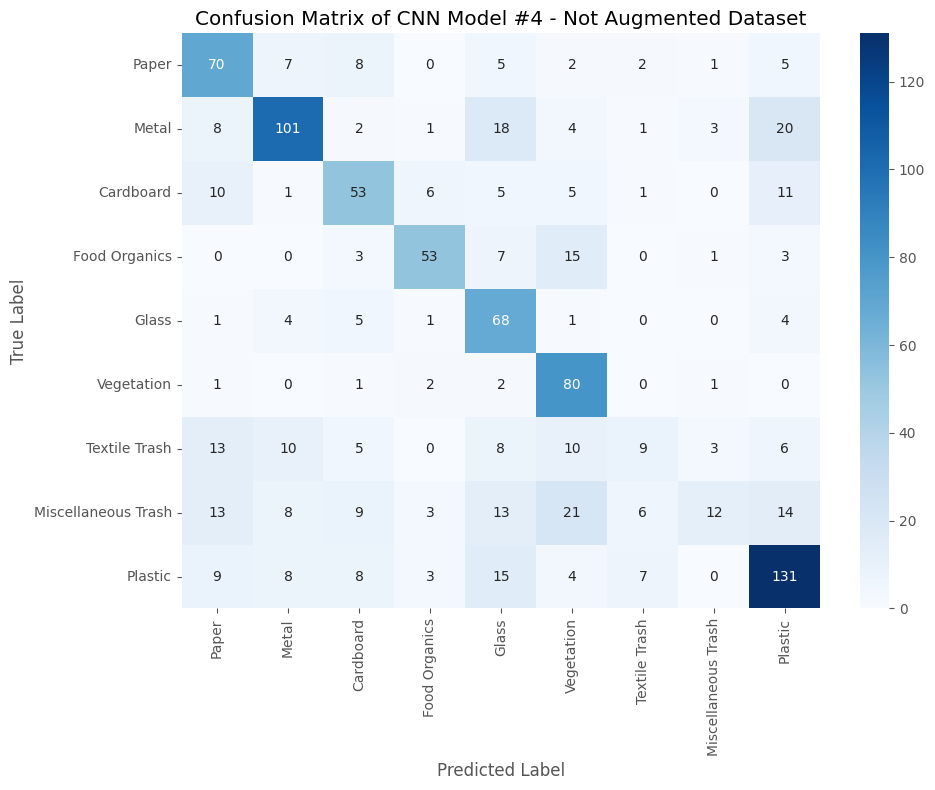

In [82]:
# confusion matrix
plot_confusion_matrix(y_true=y_test, y_pred=y_test_pred, class_map=class_map, 
                      title="Confusion Matrix of CNN Model #4 - Not Augmented Dataset")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


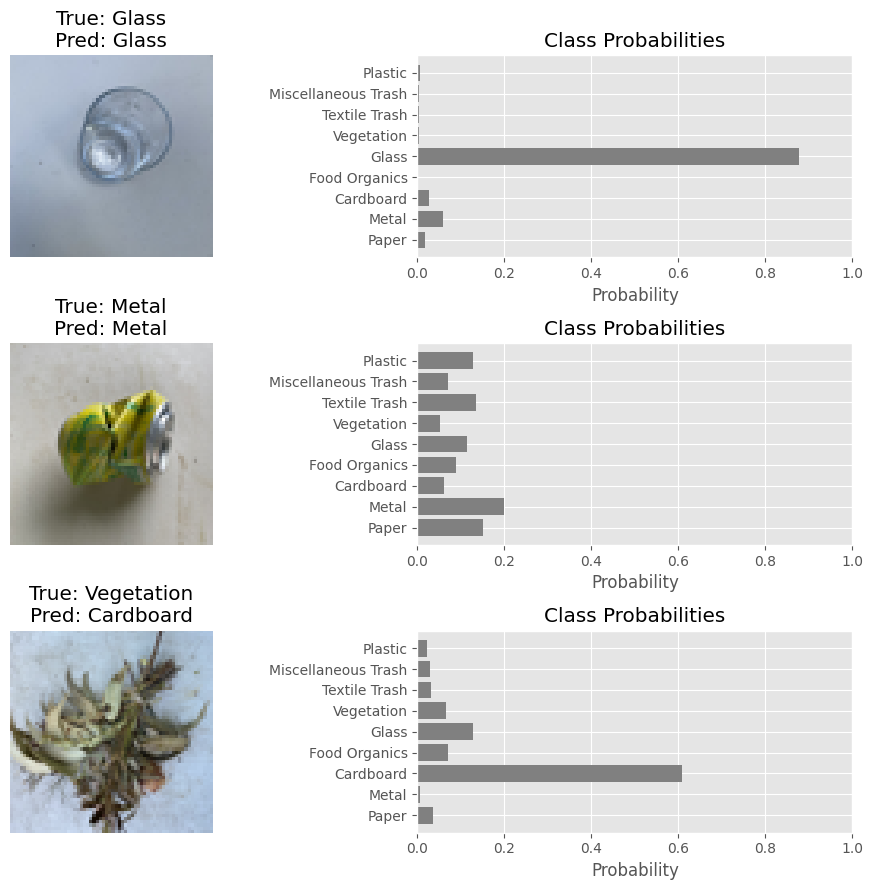

In [83]:
# Plot of 3 images with their predicted probabilities
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
random.seed(42)

inv_class_map = {v: k for k, v in class_map.items()}
for i in range(3):
    # select 3 random images from the test set
    random_idx = random.randint(0, len(X_cnn_test) - 1)
    x_sample = X_cnn_test[random_idx].reshape(1, *X_cnn_test.shape[1:])
    y_true = y_test[random_idx]

    # make predictions using the CNN model
    probs = best_cnn_model.predict(x_sample)[0]
    y_pred = np.argmax(probs)

    # plot the image
    axes[i, 0].imshow(X_cnn_test[random_idx])
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"True: {inv_class_map[y_true]}\nPred: {inv_class_map[y_pred]}")

    # plot the predicted probabilities
    class_labels = [inv_class_map[j] for j in range(len(probs))]
    axes[i, 1].barh(class_labels, probs, color='gray')
    axes[i, 1].set_xlim(0, 1)
    axes[i, 1].set_xlabel("Probability")
    axes[i, 1].set_title("Class Probabilities")

plt.tight_layout()
plt.show()

# Convolutional Neural Network - Training and Evaluation with the Augmented Dataset

In [61]:
# check whether X_cnn_train_balanced is compatible with CNN
print("X_cnn_train_balanced shape:", X_cnn_train_balanced.shape)
print("y_train_balanced shape:", y_train_balanced.shape)
# (n, x, y, z) where n is the number of images and x, y is the image dimension and z is the number of channels (RGB)

X_cnn_train_balanced shape: (5400, 64, 64, 3)
y_train_balanced shape: (5400,)


In [62]:
# first 3d array in X_cnn_train_balanced
print("First image in X_cnn_train_balanced:", X_cnn_train_balanced[0])

First image in X_cnn_train_balanced: [[[0.65882353 0.63529412 0.58823529]
  [0.65882353 0.63921569 0.59215686]
  [0.66666667 0.65098039 0.60392157]
  ...
  [0.70980392 0.69803922 0.6627451 ]
  [0.71372549 0.69803922 0.6627451 ]
  [0.72156863 0.70980392 0.66666667]]

 [[0.6627451  0.63529412 0.58823529]
  [0.66666667 0.64705882 0.6       ]
  [0.6627451  0.64705882 0.6       ]
  ...
  [0.70980392 0.69803922 0.6627451 ]
  [0.7254902  0.70980392 0.6745098 ]
  [0.71764706 0.70588235 0.67058824]]

 [[0.66666667 0.63921569 0.59215686]
  [0.66666667 0.64705882 0.6       ]
  [0.6627451  0.64313725 0.59607843]
  ...
  [0.71764706 0.70588235 0.67058824]
  [0.71764706 0.70588235 0.67058824]
  [0.7254902  0.71372549 0.67843137]]

 ...

 [[0.70588235 0.68235294 0.63137255]
  [0.70196078 0.67843137 0.62352941]
  [0.69803922 0.6745098  0.61568627]
  ...
  [0.74509804 0.71372549 0.66666667]
  [0.74901961 0.72156863 0.67058824]
  [0.74901961 0.72941176 0.66666667]]

 [[0.72156863 0.69803922 0.64705882]


/Users/ludovicofrancia/Desktop/ML WASTE PRù/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.3201 - loss: 2.0907 - val_accuracy: 0.1288 - val_loss: 2.8585 - learning_rate: 5.0000e-04
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.5198 - loss: 1.4023 - val_accuracy: 0.1551 - val_loss: 2.9363 - learning_rate: 5.0000e-04
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 71ms/step - accuracy: 0.5828 - loss: 1.1791 - val_accuracy: 0.3850 - val_loss: 1.7825 - learning_rate: 5.0000e-04
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.6454 - loss: 1.0500 - val_accuracy: 0.5966 - val_loss: 1.1391 - learning_rate: 5.0000e-04
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 84ms/step - accuracy: 0.6953 - loss: 0.9099 - val_accuracy: 0.4152 - val_loss: 1.7081 - learning_rate: 5.0000e-04
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 85ms/step - accuracy: 0.7413 - loss: 0.7800 - val_accuracy: 0.3390 - val_loss: 2.2082 - learning_rate: 5.0000e-04
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 70ms/ste

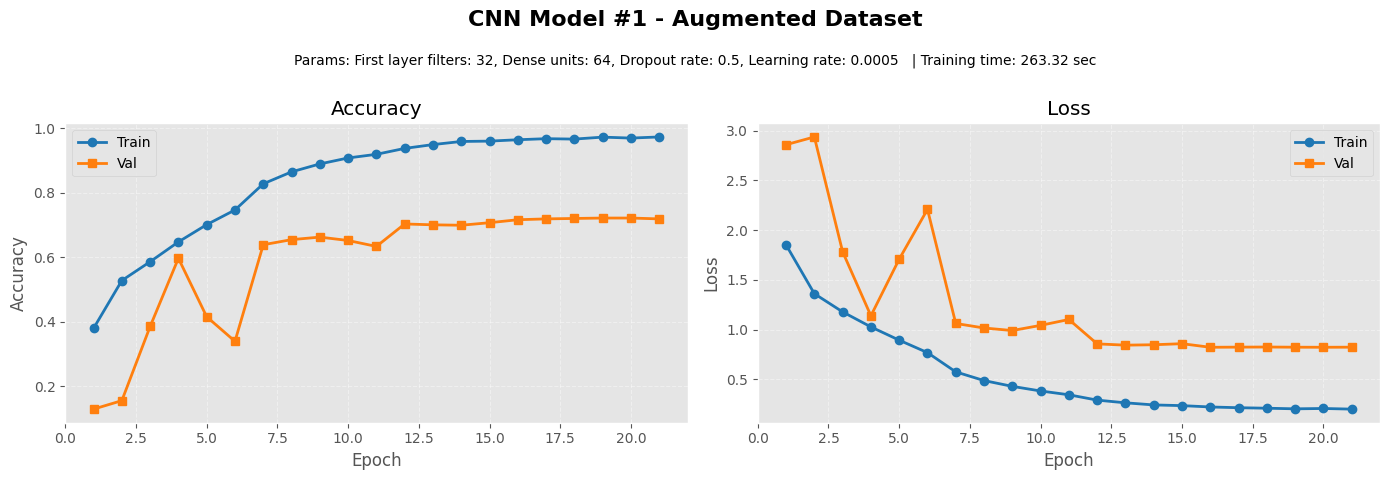

In [ ]:
# create and fit the first CNN model on the augmented dataset with the given hyperparameters
# CNN Augmented - Model 1 (BF=32, DR=0.5, LR=5e-4, Dense Units=64)
batch_size = 32
num_epochs = 30
learning_rate = 0.0005
initial_filters = 32
dense_units = 64
dropout_rate = 0.5

start_time = time.time()
fitted_model_1= create_fit_cnn_model(cnn_input_shape= cnn_input_shape, num_classes= num_classes, 
                                     initial_filters= initial_filters, dense_units= dense_units, dropout_rate= dropout_rate, 
                                     learning_rate= learning_rate,
                                     batch_size= batch_size, num_epochs= num_epochs,
                                     X_train= X_cnn_train_balanced, y_train= y_train_balanced, 
                                     X_val= X_cnn_val, y_val= y_val)
end_time = time.time()
aug_cnn_1_training_time = end_time - start_time

plot_model_history_metrics(fitted_model_1["history"], 
                           title= f"CNN Model #1 - Augmented Dataset", 
                           model_parameters= f"First layer filters: {initial_filters}, Dense units: {dense_units}, Dropout rate: {dropout_rate}, Learning rate: {learning_rate}",
                           training_time= aug_cnn_1_training_time,
                           save_img= True)

/Users/ludovicofrancia/Desktop/ML WASTE PRù/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 74ms/step - accuracy: 0.2298 - loss: 2.3622 - val_accuracy: 0.1919 - val_loss: 2.5352 - learning_rate: 1.0000e-04
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.4157 - loss: 1.7165 - val_accuracy: 0.2208 - val_loss: 2.3955 - learning_rate: 1.0000e-04
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.4923 - loss: 1.4937 - val_accuracy: 0.3535 - val_loss: 1.8565 - learning_rate: 1.0000e-04
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.5180 - loss: 1.3891 - val_accuracy: 0.5519 - val_loss: 1.2999 - learning_rate: 1.0000e-04
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.5610 - loss: 1.2712 - val_accuracy: 0.5742 - val_loss: 1.2036 - learning_rate: 1.0000e-04
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 78ms/step - accuracy: 0.5882 - loss: 1.1698 - val_accuracy: 0.6255 - val_loss: 1.1226 - learning_rate: 1.0000e-04
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 179s 1s/step

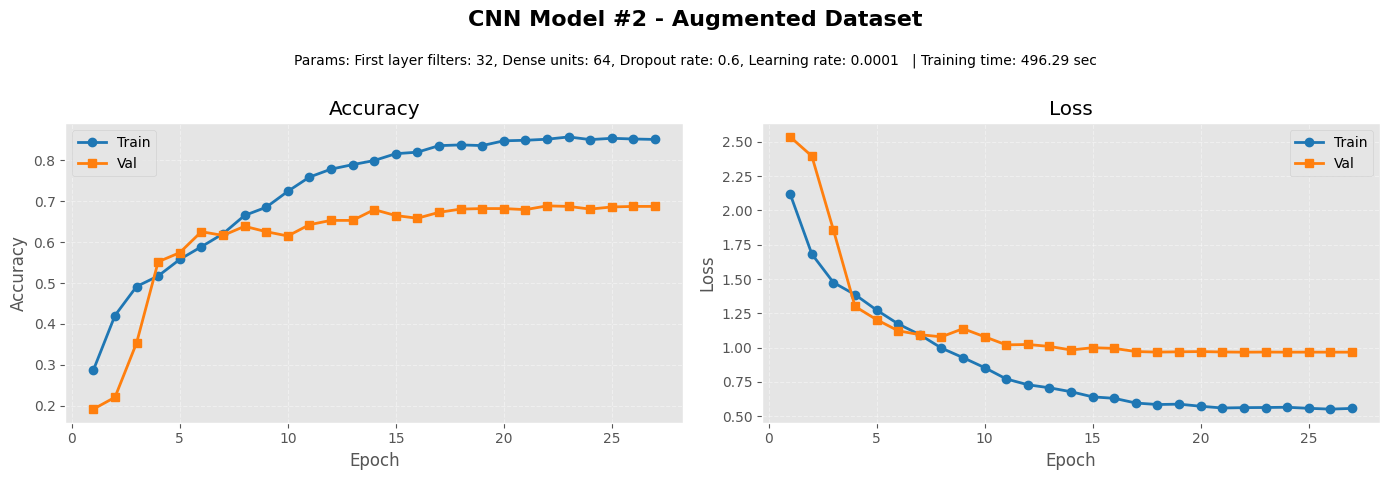

In [ ]:
# create and fit a CNN model on the augmented dataset with the given hyperparameter
# CNN Augmented - Model 2 (BF=32, DR=0.6, LR=1e-4, Dense Units=64)
batch_size = 32
num_epochs = 30
learning_rate = 0.0001
initial_filters = 32
dense_units = 64
dropout_rate = 0.6

start_time = time.time()
fitted_model_2= create_fit_cnn_model(cnn_input_shape= cnn_input_shape, num_classes= num_classes, 
                                     initial_filters= initial_filters, dense_units= dense_units, dropout_rate= dropout_rate, 
                                     learning_rate= learning_rate,
                                     batch_size= batch_size, num_epochs= num_epochs,
                                     X_train= X_cnn_train_balanced, y_train= y_train_balanced, 
                                     X_val= X_cnn_val, y_val= y_val)
end_time = time.time()
aug_cnn_2_training_time = end_time - start_time

plot_model_history_metrics(fitted_model_2["history"], 
                           title= f"CNN Model #2 - Augmented Dataset", 
                           model_parameters= f"First layer filters: {initial_filters}, Dense units: {dense_units}, Dropout rate: {dropout_rate}, Learning rate: {learning_rate}",
                           training_time= aug_cnn_2_training_time,
                           save_img= True)

/Users/ludovicofrancia/Desktop/ML WASTE PRù/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.2018 - loss: 2.4751 - val_accuracy: 0.1616 - val_loss: 2.3783 - learning_rate: 0.0010
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.3090 - loss: 1.9181 - val_accuracy: 0.2076 - val_loss: 2.3059 - learning_rate: 0.0010
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.3884 - loss: 1.7050 - val_accuracy: 0.2247 - val_loss: 2.1814 - learning_rate: 0.0010
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.4195 - loss: 1.6024 - val_accuracy: 0.2405 - val_loss: 2.2232 - learning_rate: 0.0010
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.4483 - loss: 1.5268 - val_accuracy: 0.4547 - val_loss: 1.6505 - learning_rate: 0.0010
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 72ms/step - accuracy: 0.4669 - loss: 1.4511 - val_accuracy: 0.4481 - val_loss: 1.4823 - learning_rate: 0.0010
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.5035 - l

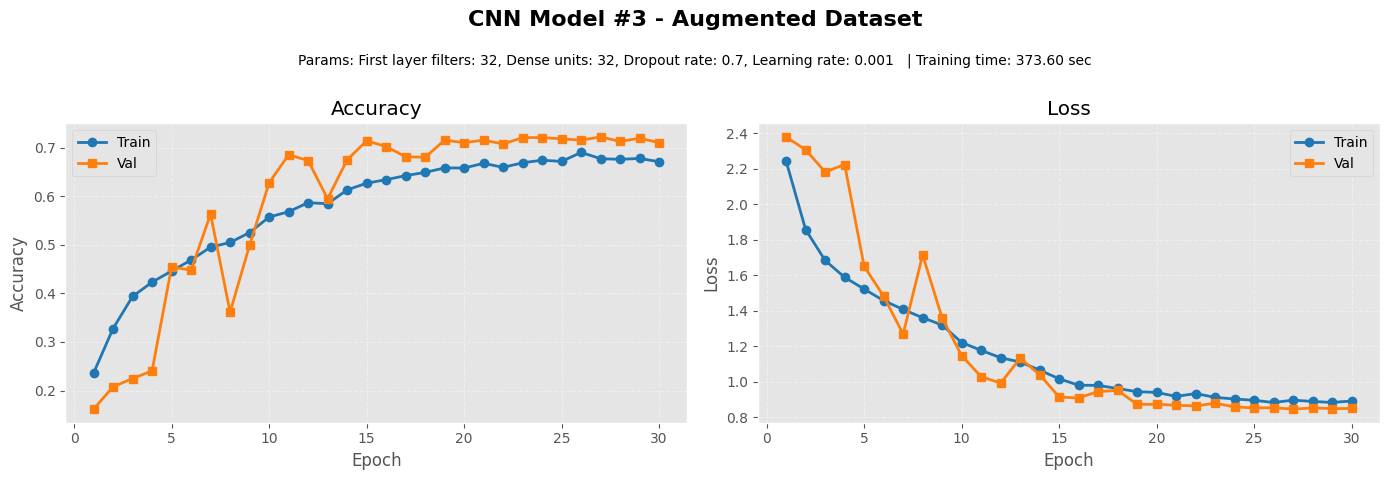

In [ ]:
# create and fit a CNN model on the augmented dataset with the given hyperparameters
# CNN Augmented - Model 3 (BF=32, DR=0.7, LR=1e-3, Dense Units=32)
batch_size = 32
num_epochs = 30
learning_rate = 0.001
initial_filters = 32
dense_units = 32
dropout_rate = 0.7

start_time = time.time()
fitted_model_3= create_fit_cnn_model(cnn_input_shape= cnn_input_shape, num_classes= num_classes, 
                                     initial_filters= initial_filters, dense_units= dense_units, dropout_rate= dropout_rate, 
                                     learning_rate= learning_rate,
                                     batch_size= batch_size, num_epochs= num_epochs,
                                     X_train= X_cnn_train_balanced, y_train= y_train_balanced, 
                                     X_val= X_cnn_val, y_val= y_val)
end_time = time.time()
aug_cnn_3_training_time = end_time - start_time

plot_model_history_metrics(fitted_model_3["history"], 
                           title= f"CNN Model #3 - Augmented Dataset", 
                           model_parameters= f"First layer filters: {initial_filters}, Dense units: {dense_units}, Dropout rate: {dropout_rate}, Learning rate: {learning_rate}",
                           training_time= aug_cnn_3_training_time,
                           save_img= True)

/Users/ludovicofrancia/Desktop/ML WASTE PRù/.venv/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.2662 - loss: 2.3361 - val_accuracy: 0.1971 - val_loss: 2.9029 - learning_rate: 0.0010
Epoch 2/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.4214 - loss: 1.6478 - val_accuracy: 0.2536 - val_loss: 2.3413 - learning_rate: 0.0010
Epoch 3/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.4837 - loss: 1.4671 - val_accuracy: 0.3995 - val_loss: 1.5843 - learning_rate: 0.0010
Epoch 4/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.5271 - loss: 1.3562 - val_accuracy: 0.2773 - val_loss: 2.3371 - learning_rate: 0.0010
Epoch 5/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.5477 - loss: 1.2969 - val_accuracy: 0.3180 - val_loss: 2.0031 - learning_rate: 0.0010
Epoch 6/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.5834 - loss: 1.1928 - val_accuracy: 0.5388 - val_loss: 1.2385 - learning_rate: 3.0000e-04
Epoch 7/30
169/169 ━━━━━━━━━━━━━━━━━━━━ 12s 73ms/step - accuracy: 0.6236

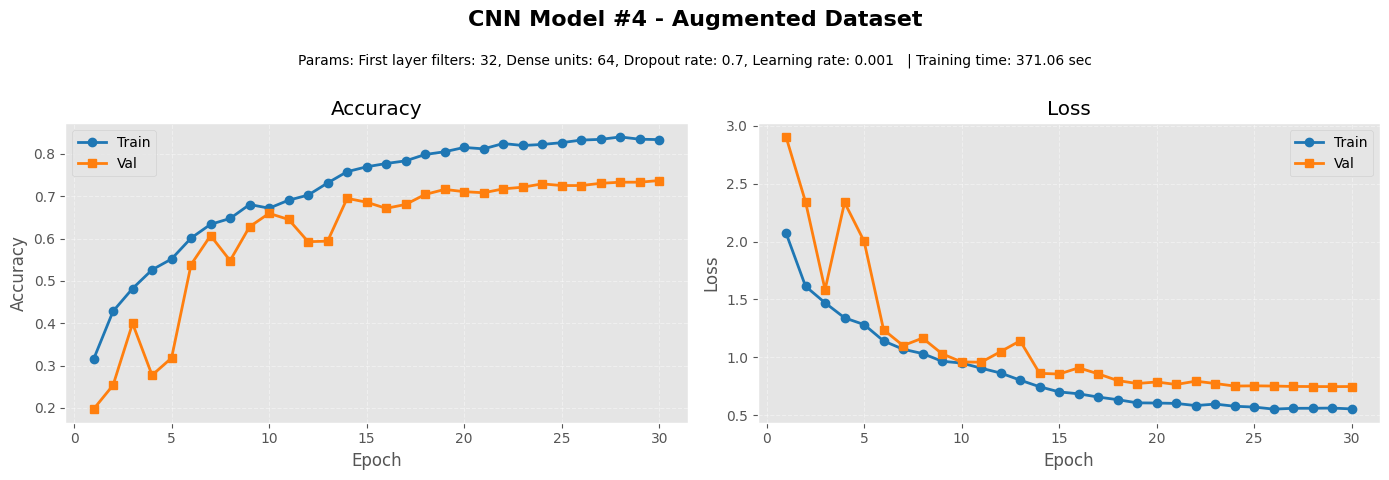

In [ ]:
# create and fit a CNN model on the augmented dataset with the given hyperparameters
# CNN Augmented - Model 4 (BF=32, DR=0.7, LR=1e-3, Dense Units=64)
batch_size = 32
num_epochs = 30
learning_rate = 0.001
initial_filters = 32
dense_units = 64
dropout_rate = 0.7

start_time = time.time()
fitted_model_4= create_fit_cnn_model(cnn_input_shape= cnn_input_shape, num_classes= num_classes, 
                                     initial_filters= initial_filters, dense_units= dense_units, dropout_rate= dropout_rate, 
                                     learning_rate= learning_rate,
                                     batch_size= batch_size, num_epochs= num_epochs,
                                     X_train= X_cnn_train_balanced, y_train= y_train_balanced, 
                                     X_val= X_cnn_val, y_val= y_val)
end_time = time.time()
aug_cnn_4_training_time = end_time - start_time

plot_model_history_metrics(fitted_model_4["history"], 
                           title= f"CNN Model #4 - Augmented Dataset", 
                           model_parameters= f"First layer filters: {initial_filters}, Dense units: {dense_units}, Dropout rate: {dropout_rate}, Learning rate: {learning_rate}",
                           training_time= aug_cnn_4_training_time,
                           save_img= True)

In [67]:
# print the structure of the model that has the best performances
best_aug_cnn_model= fitted_model_3["model"]
best_cnn_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_39 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_52          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_52 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_39 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_53          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_53 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_40 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_54          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_54 (Activation)      │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_41 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │       262,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_55          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_55 (Activation)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,069,213 (4.08 MB)

 Trainable params: 356,233 (1.36 MB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 712,468 (2.72 MB)

In [73]:
# predictions using the best model
y_test_pred = best_aug_cnn_model.predict(X_cnn_test)
y_test_pred = np.argmax(y_test_pred, axis=1) # get the class with the highest probability

# classification report
print(classification_report(y_test, y_test_pred, target_names=list(class_map.keys())))

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
                     precision    recall  f1-score   support

              Paper       0.66      0.73      0.70       100
              Metal       0.75      0.70      0.72       158
          Cardboard       0.68      0.60      0.64        92
      Food Organics       0.72      0.83      0.77        82
              Glass       0.79      0.81      0.80        84
         Vegetation       0.84      0.94      0.89        87
      Textile Trash       0.51      0.53      0.52        64
Miscellaneous Trash       0.45      0.29      0.36        99
            Plastic       0.71      0.78      0.75       185

           accuracy                           0.70       951
          macro avg       0.68      0.69      0.68       951
       weighted avg       0.69      0.70      0.69       951



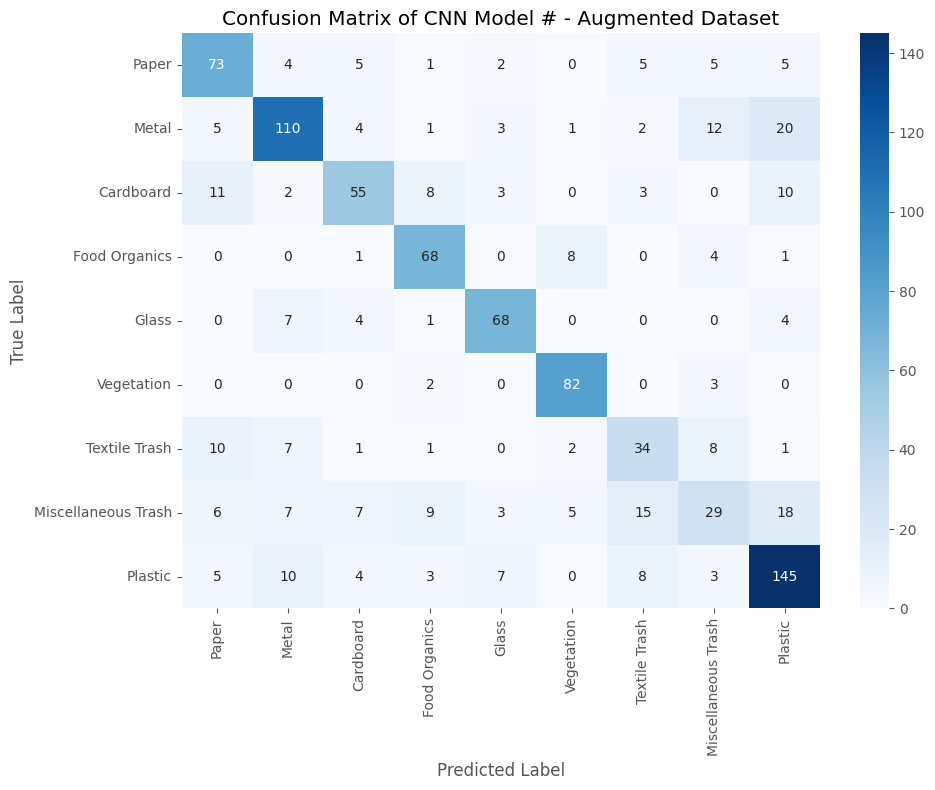

In [74]:
# confusion matrix
plot_confusion_matrix(y_true=y_test, y_pred=y_test_pred, class_map=class_map, 
                      title="Confusion Matrix of CNN Model # - Augmented Dataset")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


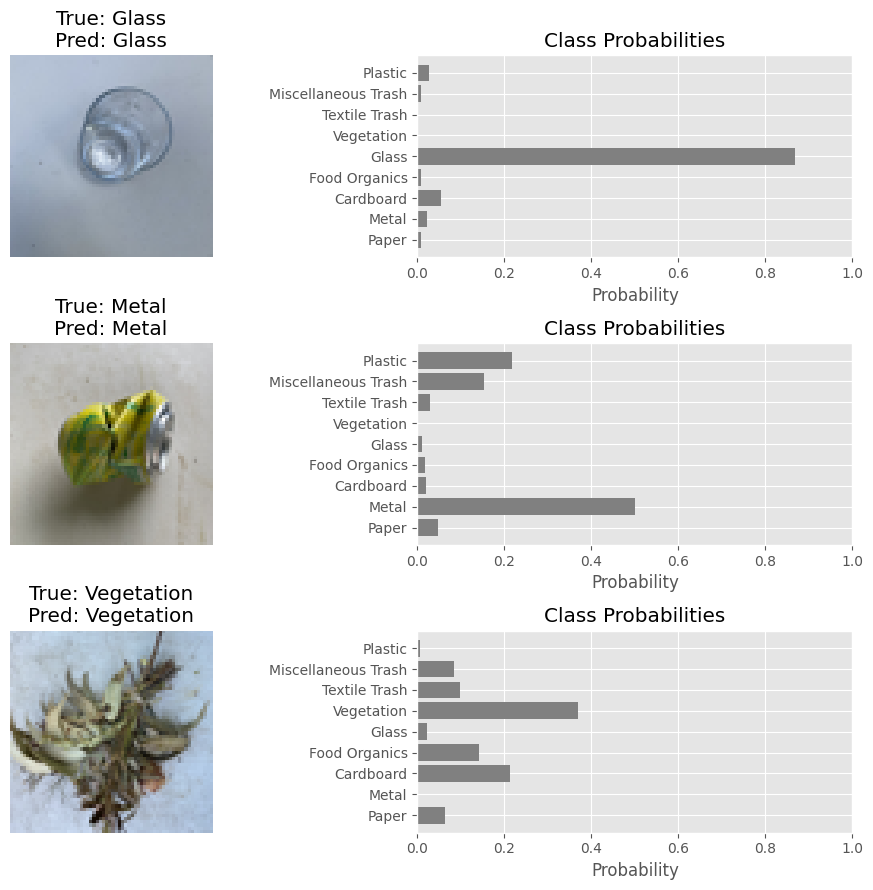

In [76]:
# Plot of 3 images with their predicted probabilities
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 9))
random.seed(42)

inv_class_map = {v: k for k, v in class_map.items()}
for i in range(3):
    # select 3 random images from the test set
    random_idx = random.randint(0, len(X_cnn_test) - 1)
    x_sample = X_cnn_test[random_idx].reshape(1, *X_cnn_test.shape[1:])
    y_true = y_test[random_idx]

    # make predictions using the CNN model
    probs = best_aug_cnn_model.predict(x_sample)[0]
    y_pred = np.argmax(probs)

    # plot the image
    axes[i, 0].imshow(X_cnn_test[random_idx])
    axes[i, 0].axis('off')
    axes[i, 0].set_title(f"True: {inv_class_map[y_true]}\nPred: {inv_class_map[y_pred]}")

    # plot the predicted probabilities
    class_labels = [inv_class_map[j] for j in range(len(probs))]
    axes[i, 1].barh(class_labels, probs, color='gray')
    axes[i, 1].set_xlim(0, 1)
    axes[i, 1].set_xlabel("Probability")
    axes[i, 1].set_title("Class Probabilities")

plt.tight_layout()
plt.show()